# Cell 1: Environment setup

In [1]:
# Cell 1: Environment setup - verify dependencies, GPU availability, dataset path, and set global seed
import sys
import os
import random
import numpy as np
import torch
import torchvision
from pathlib import Path

# Set global seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Print environment info
print("="*60)
print("ENVIRONMENT CONFIGURATION")
print("="*60)
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print(f"cuDNN version: {torch.backends.cudnn.version() if torch.cuda.is_available() else 'N/A'}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB)")
print(f"Global seed: {SEED}")
print("="*60)

# Verify dataset path
DATASET_PATH = Path("/kaggle/input/axialct-kidneystone-annotated")
print(f"\nDataset path: {DATASET_PATH}")
print(f"Dataset exists: {DATASET_PATH.exists()}")
if DATASET_PATH.exists():
    print("\nDataset structure:")
    for item in sorted(DATASET_PATH.iterdir()):
        if item.is_dir():
            img_count = len(list((item / "images").glob("*"))) if (item / "images").exists() else 0
            lbl_count = len(list((item / "labels").glob("*"))) if (item / "labels").exists() else 0
            print(f"  {item.name}/ - images: {img_count}, labels: {lbl_count}")
        else:
            print(f"  {item.name}")
print("="*60)

ENVIRONMENT CONFIGURATION
Python version: 3.11.13
PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
CUDA available: True
CUDA version: 12.4
cuDNN version: 90300
GPU count: 2
  GPU 0: Tesla T4 (15.83 GB)
  GPU 1: Tesla T4 (15.83 GB)
Global seed: 42

Dataset path: /kaggle/input/axialct-kidneystone-annotated
Dataset exists: True

Dataset structure:
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  test/ - images: 76, labels: 76
  train/ - images: 4080, labels: 4080
  valid/ - images: 78, labels: 78


# Cell 2: Install required dependencies

In [2]:
# Cell 2: Install required dependencies - timm, albumentations, ultralytics, pycocotools (fixed version check)
import subprocess
import sys

packages_to_install = [
    'timm',
    'albumentations',
    'ultralytics',
    'pycocotools',
    'opencv-python-headless',
]

print("="*60)
print("INSTALLING REQUIRED PACKAGES")
print("="*60)

for package in packages_to_install:
    try:
        __import__(package.replace('-', '_').split('[')[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print(f"✓ {package} installed successfully")

print("="*60)
print("VERIFYING INSTALLED VERSIONS")
print("="*60)

import timm
import albumentations as A
import ultralytics
import cv2

print(f"timm version: {timm.__version__}")
print(f"albumentations version: {A.__version__}")
print(f"ultralytics version: {ultralytics.__version__}")
print(f"opencv version: {cv2.__version__}")
print(f"pycocotools: installed (no version attribute)")
print("="*60)

INSTALLING REQUIRED PACKAGES


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✓ timm already installed
✓ albumentations already installed
Installing ultralytics...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
mkl-umath 0.1.1 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-random 1.2.4 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
mkl-fft 1.3.8 requires numpy<1.27.0,>=1.26.4, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is in

✓ ultralytics installed successfully
✓ pycocotools already installed
Installing opencv-python-headless...
✓ opencv-python-headless installed successfully
VERIFYING INSTALLED VERSIONS
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
timm version: 1.0.19
albumentations version: 2.0.8
ultralytics version: 8.3.225
opencv version: 4.12.0
pycocotools: installed (no version attribute)


# Cell 3: Data validation

In [3]:
# Cell 3: Data validation and re-split dataset into 80-10-10 ratio with stratification
import yaml
from pathlib import Path
import cv2
import numpy as np
import shutil
from collections import Counter
from sklearn.model_selection import train_test_split

DATASET_PATH = Path("/kaggle/input/axialct-kidneystone-annotated")
OUTPUT_PATH = Path("/kaggle/working/dataset")

print("="*60)
print("DATASET VALIDATION & RE-SPLITTING (80-10-10)")
print("="*60)

# Load data.yaml
yaml_path = DATASET_PATH / "data.yaml"
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print(f"\nOriginal dataset configuration:")
print(f"  Classes: {data_config.get('names', 'N/A')}")
print(f"  Number of classes: {data_config.get('nc', 'N/A')}")

# Collect all images and labels from all splits
all_images = []
all_labels = []

for split in ['train', 'valid', 'test']:
    img_dir = DATASET_PATH / split / "images"
    lbl_dir = DATASET_PATH / split / "labels"
    
    for img_file in img_dir.glob("*.jpg"):
        lbl_file = lbl_dir / f"{img_file.stem}.txt"
        if lbl_file.exists():
            all_images.append(img_file)
            all_labels.append(lbl_file)
    
    for img_file in img_dir.glob("*.png"):
        lbl_file = lbl_dir / f"{img_file.stem}.txt"
        if lbl_file.exists():
            all_images.append(img_file)
            all_labels.append(lbl_file)

print(f"\nTotal matched image-label pairs: {len(all_images)}")

# Count objects per image for stratification
print("\nAnalyzing object distribution for stratification...")

def count_objects(label_file):
    with open(label_file, 'r') as f:
        return len(f.readlines())

object_counts = [count_objects(lbl) for lbl in all_labels]

# Show distribution
count_dist = Counter(object_counts)
print(f"\nObject count distribution:")
for count in sorted(count_dist.keys()):
    print(f"  {count} stone(s): {count_dist[count]} images ({count_dist[count]/len(all_images)*100:.1f}%)")

# Create strata bins (group similar counts to avoid too many small classes)
strata = []
for count in object_counts:
    if count <= 1:
        strata.append('very_few')
    elif count <= 3:
        strata.append('few')
    elif count <= 6:
        strata.append('medium')
    else:
        strata.append('many')

strata_dist = Counter(strata)
print(f"\nStratification groups:")
for group, count in strata_dist.items():
    print(f"  {group}: {count} images ({count/len(all_images)*100:.1f}%)")

# Stratified split 80-10-10
print("\nPerforming stratified split...")
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=strata
)

# Get strata for temp set
temp_strata = [strata[all_labels.index(lbl)] for lbl in temp_lbls]

val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls, test_size=0.5, random_state=42, stratify=temp_strata
)

print(f"\nNew split distribution:")
print(f"  Train: {len(train_imgs)} ({len(train_imgs)/len(all_images)*100:.1f}%)")
print(f"  Valid: {len(val_imgs)} ({len(val_imgs)/len(all_images)*100:.1f}%)")
print(f"  Test: {len(test_imgs)} ({len(test_imgs)/len(all_images)*100:.1f}%)")

# Create new directory structure
for split in ['train', 'valid', 'test']:
    (OUTPUT_PATH / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_PATH / split / "labels").mkdir(parents=True, exist_ok=True)

# Copy files to new structure
print("\nCopying files to new structure...")
for img, lbl in zip(train_imgs, train_lbls):
    shutil.copy(img, OUTPUT_PATH / "train" / "images" / img.name)
    shutil.copy(lbl, OUTPUT_PATH / "train" / "labels" / lbl.name)

for img, lbl in zip(val_imgs, val_lbls):
    shutil.copy(img, OUTPUT_PATH / "valid" / "images" / img.name)
    shutil.copy(lbl, OUTPUT_PATH / "valid" / "labels" / lbl.name)

for img, lbl in zip(test_imgs, test_lbls):
    shutil.copy(img, OUTPUT_PATH / "test" / "images" / img.name)
    shutil.copy(lbl, OUTPUT_PATH / "test" / "labels" / lbl.name)

# Create new data.yaml
new_yaml = {
    'path': str(OUTPUT_PATH),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': data_config.get('nc'),
    'names': data_config.get('names')
}

with open(OUTPUT_PATH / "data.yaml", 'w') as f:
    yaml.dump(new_yaml, f)

print("✓ Dataset re-split complete with stratification")
print(f"✓ New dataset path: {OUTPUT_PATH}")
print("="*60)

DATASET VALIDATION & RE-SPLITTING (80-10-10)

Original dataset configuration:
  Classes: ['calcium']
  Number of classes: 1

Total matched image-label pairs: 4234

Analyzing object distribution for stratification...

Object count distribution:
  1 stone(s): 15 images (0.4%)
  2 stone(s): 701 images (16.6%)
  3 stone(s): 838 images (19.8%)
  4 stone(s): 599 images (14.1%)
  5 stone(s): 587 images (13.9%)
  6 stone(s): 509 images (12.0%)
  7 stone(s): 413 images (9.8%)
  8 stone(s): 208 images (4.9%)
  9 stone(s): 131 images (3.1%)
  10 stone(s): 120 images (2.8%)
  11 stone(s): 66 images (1.6%)
  12 stone(s): 13 images (0.3%)
  13 stone(s): 15 images (0.4%)
  14 stone(s): 15 images (0.4%)
  15 stone(s): 4 images (0.1%)

Stratification groups:
  medium: 1695 images (40.0%)
  few: 1539 images (36.3%)
  many: 985 images (23.3%)
  very_few: 15 images (0.4%)

Performing stratified split...

New split distribution:
  Train: 3387 (80.0%)
  Valid: 423 (10.0%)
  Test: 424 (10.0%)

Copying files 

# Cell 4: Data augmentation

In [4]:
# Cell 4: BYOL augmentation pipeline and dataset class for self-supervised pretraining
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
from pathlib import Path
import numpy as np

class BYOLAugmentation:
    def __init__(self, image_size=640):
        self.image_size = image_size
        
        # Strong augmentation view
        self.strong_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=20, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
            A.GaussianBlur(blur_limit=(3, 7), p=0.5),
            A.GaussNoise(std_limit=(10.0, 50.0), p=0.5),  # Fixed: var_limit -> std_limit
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),  # Fixed: removed alpha_affine
            A.GridDistortion(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
        
        # Weak augmentation view
        self.weak_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    
    def __call__(self, image):
        view1 = self.strong_transform(image=image)['image']
        view2 = self.weak_transform(image=image)['image']
        return view1, view2

class BYOLDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = sorted(list(Path(image_dir).glob("*.jpg")) + list(Path(image_dir).glob("*.png")))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transform:
            view1, view2 = self.transform(image)
            return view1, view2
        return image

DATASET_PATH = Path("/kaggle/working/dataset")
IMAGE_SIZE = 640
BATCH_SIZE = 16

print("="*60)
print("BYOL AUGMENTATION PIPELINE SETUP")
print("="*60)

# Create augmentation pipeline
byol_aug = BYOLAugmentation(image_size=IMAGE_SIZE)

# Collect all images for SSL (train + valid + test, no labels needed)
all_image_dirs = [
    DATASET_PATH / "train" / "images",
    DATASET_PATH / "valid" / "images",
    DATASET_PATH / "test" / "images"
]

all_ssl_images = []
for img_dir in all_image_dirs:
    all_ssl_images.extend(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))

print(f"Total images for SSL pretraining: {len(all_ssl_images)}")

# Create SSL dataset and dataloader
ssl_dataset = BYOLDataset(DATASET_PATH / "train" / "images", transform=byol_aug)
ssl_dataset.image_paths = all_ssl_images

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print(f"SSL DataLoader: {len(ssl_loader)} batches (batch_size={BATCH_SIZE})")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")

# Test augmentation pipeline
sample_img = cv2.imread(str(all_ssl_images[0]))
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
view1, view2 = byol_aug(sample_img)

print(f"\nAugmentation test:")
print(f"  View 1 shape: {view1.shape}")
print(f"  View 2 shape: {view2.shape}")
print("="*60)

BYOL AUGMENTATION PIPELINE SETUP
Total images for SSL pretraining: 4234
SSL DataLoader: 264 batches (batch_size=16)
Image size: 640x640

Augmentation test:
  View 1 shape: torch.Size([3, 640, 640])
  View 2 shape: torch.Size([3, 640, 640])


/tmp/ipykernel_19/599766809.py:22: UserWarning: Argument(s) 'std_limit' are not valid for transform GaussNoise
  A.GaussNoise(std_limit=(10.0, 50.0), p=0.5),  # Fixed: var_limit -> std_limit


# Cell 5: YOLOv12 backbone extraction and BYOL model architecture

In [5]:
# Cell 5: YOLOv12m backbone extraction and BYOL model architecture
import torch
import torch.nn as nn
import torch.nn.functional as F
from ultralytics import YOLO
import copy

# Disable cuDNN for stability
torch.backends.cudnn.enabled = False

class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class PredictionHead(nn.Module):
    def __init__(self, in_dim=256, hidden_dim=2048, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class BYOLModel(nn.Module):
    def __init__(self, backbone, hidden_dim=2048, projection_dim=256, moving_average_decay=0.996, device='cuda'):
        super().__init__()
        self.backbone = backbone
        self.moving_average_decay = moving_average_decay
        self.device = device
        
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 640, 640).to(device)
            backbone_out = self.backbone(dummy_input)
            if isinstance(backbone_out, (list, tuple)):
                backbone_out = backbone_out[-1]
            self.backbone_dim = backbone_out.shape[1]
        
        self.online_projector = ProjectionHead(self.backbone_dim, hidden_dim, projection_dim)
        self.online_predictor = PredictionHead(projection_dim, hidden_dim, projection_dim)
        
        self.target_backbone = copy.deepcopy(self.backbone)
        self.target_projector = copy.deepcopy(self.online_projector)
        
        for param in self.target_backbone.parameters():
            param.requires_grad = False
        for param in self.target_projector.parameters():
            param.requires_grad = False
    
    def forward(self, x1, x2):
        online_feat1 = self.backbone(x1)
        if isinstance(online_feat1, (list, tuple)):
            online_feat1 = online_feat1[-1]
        online_feat1 = F.adaptive_avg_pool2d(online_feat1, 1).flatten(1)
        online_proj1 = self.online_projector(online_feat1)
        online_pred1 = self.online_predictor(online_proj1)
        
        online_feat2 = self.backbone(x2)
        if isinstance(online_feat2, (list, tuple)):
            online_feat2 = online_feat2[-1]
        online_feat2 = F.adaptive_avg_pool2d(online_feat2, 1).flatten(1)
        online_proj2 = self.online_projector(online_feat2)
        online_pred2 = self.online_predictor(online_proj2)
        
        with torch.no_grad():
            target_feat1 = self.target_backbone(x1)
            if isinstance(target_feat1, (list, tuple)):
                target_feat1 = target_feat1[-1]
            target_feat1 = F.adaptive_avg_pool2d(target_feat1, 1).flatten(1)
            target_proj1 = self.target_projector(target_feat1)
            
            target_feat2 = self.target_backbone(x2)
            if isinstance(target_feat2, (list, tuple)):
                target_feat2 = target_feat2[-1]
            target_feat2 = F.adaptive_avg_pool2d(target_feat2, 1).flatten(1)
            target_proj2 = self.target_projector(target_feat2)
        
        return online_pred1, online_pred2, target_proj1.detach(), target_proj2.detach()
    
    @torch.no_grad()
    def update_target_network(self):
        for online_params, target_params in zip(self.backbone.parameters(), self.target_backbone.parameters()):
            target_params.data = self.moving_average_decay * target_params.data + (1 - self.moving_average_decay) * online_params.data
        
        for online_params, target_params in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            target_params.data = self.moving_average_decay * target_params.data + (1 - self.moving_average_decay) * online_params.data

def byol_loss(pred, target):
    pred = F.normalize(pred, dim=-1, p=2)
    target = F.normalize(target, dim=-1, p=2)
    return 2 - 2 * (pred * target).sum(dim=-1).mean()

print("="*60)
print("BYOL MODEL INITIALIZATION - YOLOv12s")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load YOLOv12m and extract backbone
try:
    yolo_model = YOLO("yolo12s.pt")
    print("Loaded: YOLOv12s pretrained weights")
    backbone = yolo_model.model.model[:10]
except Exception as e:
    print(f"YOLOv12m not available ({str(e)}), trying yolo11m.pt...")
    try:
        yolo_model = YOLO("yolo11m.pt")
        print("Loaded: YOLOv11m pretrained weights")
        backbone = yolo_model.model.model[:10]
    except Exception as e2:
        print(f"YOLOv11m failed ({str(e2)}), checking available models...")
        raise ValueError("YOLOv12m/v11m not available. Please check ultralytics version.")

backbone = backbone.to(device)

# Create BYOL model
byol_model = BYOLModel(backbone, hidden_dim=2048, projection_dim=256, moving_average_decay=0.996, device=device)
byol_model = byol_model.to(device)

# Count parameters
total_params = sum(p.numel() for p in byol_model.parameters())
trainable_params = sum(p.numel() for p in byol_model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"cuDNN enabled: {torch.backends.cudnn.enabled}")
print(f"Backbone dimension: {byol_model.backbone_dim}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Target network frozen: ✓")
print("="*60)

BYOL MODEL INITIALIZATION - YOLOv12s
Loaded: YOLOv12s pretrained weights
Device: cuda
cuDNN enabled: False
Backbone dimension: 512
Total parameters: 15,109,760
Trainable parameters: 2,634,240
Target network frozen: ✓


# Cell 6: BYOL self-supervised pretraining loop

In [6]:
# Cell 6: BYOL self-supervised pretraining (50 epochs, YOLOv12s, 512×512, batch=24)
import torch
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

BYOL_EPOCHS = 50
BYOL_LR = 3e-4
BYOL_WEIGHT_DECAY = 1e-6
BATCH_SIZE_BYOL = 24  # Increased for smaller model
IMAGE_SIZE_BYOL = 512  # Reduced from 640
SAVE_EVERY = 10

print("="*60)
print(f"BYOL SELF-SUPERVISED PRETRAINING ({BYOL_EPOCHS} EPOCHS)")
print("="*60)
print(f"Configuration:")
print(f"  Random seed: {SEED}")
print(f"  Device: {device}")
print(f"  cuDNN enabled: {torch.backends.cudnn.enabled}")
print(f"  Model: YOLOv12s (small)")
print(f"  Image size: {IMAGE_SIZE_BYOL}×{IMAGE_SIZE_BYOL}")
print(f"  Epochs: {BYOL_EPOCHS}")
print(f"  Batch size: {BATCH_SIZE_BYOL}")
print(f"  Learning rate: {BYOL_LR}")
print(f"  Weight decay: {BYOL_WEIGHT_DECAY}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Images: {len(ssl_dataset):,}")
print("="*60)

# Recreate augmentation with 512×512
from albumentations.pytorch import ToTensorV2
import albumentations as A

class BYOLAugmentation512:
    def __init__(self, image_size=512):
        self.image_size = image_size
        
        self.strong_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=20, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
            A.GaussianBlur(blur_limit=(3, 7), p=0.5),
            A.GaussNoise(std_limit=(10.0, 50.0), p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.GridDistortion(p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
        
        self.weak_transform = A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    
    def __call__(self, image):
        view1 = self.strong_transform(image=image)['image']
        view2 = self.weak_transform(image=image)['image']
        return view1, view2

# Update dataset with new augmentation
print("\nUpdating augmentation pipeline for 512×512...")
ssl_dataset.transform = BYOLAugmentation512(image_size=IMAGE_SIZE_BYOL)

# Recreate dataloader with new batch size
ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=BATCH_SIZE_BYOL,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

batches_per_epoch = len(ssl_loader)
print(f"Batches per epoch: {batches_per_epoch}")
print(f"Estimated time per epoch: ~3-5 minutes")
print(f"Total estimated time: ~2.5-4 hours")

# Optimizer
optimizer = torch.optim.AdamW(
    [p for p in byol_model.parameters() if p.requires_grad],
    lr=BYOL_LR,
    weight_decay=BYOL_WEIGHT_DECAY
)

# Learning rate scheduler (cosine annealing)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=BYOL_EPOCHS,
    eta_min=1e-6
)

# Mixed precision scaler
scaler = GradScaler()

# Training tracking
loss_history = []
best_loss = float('inf')
start_time = time.time()

print("\nStarting training...")
print("="*60)

byol_model.train()

for epoch in range(BYOL_EPOCHS):
    epoch_loss = 0.0
    epoch_start = time.time()
    
    pbar = tqdm(ssl_loader, desc=f"Epoch {epoch+1}/{BYOL_EPOCHS}")
    
    for batch_idx, (view1, view2) in enumerate(pbar):
        view1 = view1.to(device, non_blocking=True)
        view2 = view2.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass (disable autocast without cuDNN for slight speedup)
        with autocast(enabled=False):
            online_pred1, online_pred2, target_proj1, target_proj2 = byol_model(view1, view2)
            
            # Symmetric BYOL loss
            loss1 = byol_loss(online_pred1, target_proj2)
            loss2 = byol_loss(online_pred2, target_proj1)
            loss = loss1 + loss2
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Update target network (EMA)
        byol_model.update_target_network()
        
        epoch_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
    
    # Epoch statistics
    avg_loss = epoch_loss / batches_per_epoch
    loss_history.append(avg_loss)
    epoch_time = time.time() - epoch_start
    elapsed_time = time.time() - start_time
    
    scheduler.step()
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{BYOL_EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
          f"Time: {epoch_time:.1f}s | "
          f"Elapsed: {elapsed_time/60:.1f}min")
    
    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch': epoch + 1,
            'model_name': 'YOLOv12s',
            'backbone_state_dict': byol_model.backbone.state_dict(),
            'online_projector': byol_model.online_projector.state_dict(),
            'loss': best_loss,
            'loss_history': loss_history,
            'config': {
                'image_size': IMAGE_SIZE_BYOL,
                'batch_size': BATCH_SIZE_BYOL,
                'epochs': BYOL_EPOCHS,
                'lr': BYOL_LR
            }
        }, '/kaggle/working/byol_yolov12s_best.pth')
        print(f"  ✓ Best model saved (loss: {best_loss:.4f})")
    
    # Save periodic checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch + 1,
            'model_name': 'YOLOv12s',
            'backbone_state_dict': byol_model.backbone.state_dict(),
            'online_projector': byol_model.online_projector.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'loss': avg_loss,
            'loss_history': loss_history,
            'config': {
                'image_size': IMAGE_SIZE_BYOL,
                'batch_size': BATCH_SIZE_BYOL,
                'epochs': BYOL_EPOCHS,
                'lr': BYOL_LR
            }
        }, f'/kaggle/working/byol_yolov12s_epoch_{epoch+1}.pth')
        print(f"  ✓ Checkpoint saved: epoch {epoch+1}")
    
    # Early stopping check (optional - if loss plateaus)
    if epoch > 20 and len(loss_history) > 5:
        recent_losses = loss_history[-5:]
        if max(recent_losses) - min(recent_losses) < 0.001:
            print(f"\n⚠ Loss plateaued - consider early stopping")

total_time = time.time() - start_time

print("="*60)
print("BYOL PRETRAINING COMPLETE")
print("="*60)
print(f"Total time: {total_time/3600:.2f} hours ({total_time/60:.1f} minutes)")
print(f"Best loss: {best_loss:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Average time per epoch: {total_time/BYOL_EPOCHS:.1f}s")
print(f"Pretrained backbone saved: /kaggle/working/byol_yolov12s_best.pth")
print("="*60)

# Plot training curve
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(loss_history, linewidth=2, color='#2E86AB')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('BYOL Loss', fontsize=11)
plt.title(f'BYOL Pretraining Loss (YOLOv12s, 512×512, batch={BATCH_SIZE_BYOL})', fontsize=12)
plt.grid(True, alpha=0.3)

# Loss smoothed (moving average)
plt.subplot(1, 2, 2)
if len(loss_history) > 5:
    import numpy as np
    window = 5
    smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(loss_history)), smoothed, linewidth=2, color='#A23B72', label='Smoothed (MA-5)')
    plt.plot(loss_history, linewidth=1, alpha=0.3, color='#2E86AB', label='Raw')
    plt.legend()
else:
    plt.plot(loss_history, linewidth=2, color='#A23B72')

plt.xlabel('Epoch', fontsize=11)
plt.ylabel('BYOL Loss', fontsize=11)
plt.title('Loss Trend (Smoothed)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/byol_loss_curve.png', dpi=150, bbox_inches='tight')
plt.close()

print("✓ Loss curve saved: /kaggle/working/byol_loss_curve.png")

# Save training summary
summary = {
    'model': 'YOLOv12s',
    'total_epochs': BYOL_EPOCHS,
    'image_size': IMAGE_SIZE_BYOL,
    'batch_size': BATCH_SIZE_BYOL,
    'best_loss': best_loss,
    'final_loss': loss_history[-1],
    'total_time_hours': total_time/3600,
    'avg_time_per_epoch_sec': total_time/BYOL_EPOCHS,
    'total_params': total_params,
    'trainable_params': trainable_params
}

import json
with open('/kaggle/working/byol_training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✓ Training summary saved: /kaggle/working/byol_training_summary.json")
print("\n✓ Ready for YOLOv12 fine-tuning phase")


/tmp/ipykernel_19/2360478883.py:48: UserWarning: Argument(s) 'std_limit' are not valid for transform GaussNoise
  A.GaussNoise(std_limit=(10.0, 50.0), p=0.5),
/tmp/ipykernel_19/2360478883.py:102: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


BYOL SELF-SUPERVISED PRETRAINING (50 EPOCHS)
Configuration:
  Random seed: 42
  Device: cuda
  cuDNN enabled: False
  Model: YOLOv12s (small)
  Image size: 512×512
  Epochs: 50
  Batch size: 24
  Learning rate: 0.0003
  Weight decay: 1e-06
  Trainable params: 2,634,240
  Images: 4,234

Updating augmentation pipeline for 512×512...
Batches per epoch: 176
Estimated time per epoch: ~3-5 minutes
Total estimated time: ~2.5-4 hours

Starting training...


Epoch 1/50:   0%|          | 0/176 [00:00<?, ?it/s]/tmp/ipykernel_19/2360478883.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=False):
Epoch 1/50: 100%|██████████| 176/176 [02:47<00:00,  1.05it/s, loss=1.5813, lr=3.00e-04]


Epoch 1/50 | Loss: 1.6212 | LR: 3.00e-04 | Time: 167.2s | Elapsed: 2.8min
  ✓ Best model saved (loss: 1.6212)


Epoch 2/50: 100%|██████████| 176/176 [02:46<00:00,  1.06it/s, loss=1.4611, lr=3.00e-04]


...

Epoch 48/50 | Loss: 0.5420 | LR: 2.18e-06 | Time: 169.1s | Elapsed: 134.9min
  ✓ Best model saved (loss: 0.5420)


Epoch 49/50: 100%|██████████| 176/176 [02:46<00:00,  1.06it/s, loss=0.5061, lr=2.18e-06]


Epoch 49/50 | Loss: 0.5358 | LR: 1.30e-06 | Time: 166.5s | Elapsed: 137.7min
  ✓ Best model saved (loss: 0.5358)


Epoch 50/50: 100%|██████████| 176/176 [02:48<00:00,  1.05it/s, loss=0.5197, lr=1.30e-06]


Epoch 50/50 | Loss: 0.5460 | LR: 1.00e-06 | Time: 168.1s | Elapsed: 140.5min
  ✓ Checkpoint saved: epoch 50
BYOL PRETRAINING COMPLETE
Total time: 2.34 hours (140.5 minutes)
Best loss: 0.5358
Final loss: 0.5460
Average time per epoch: 168.6s
Pretrained backbone saved: /kaggle/working/byol_yolov12s_best.pth
✓ Loss curve saved: /kaggle/working/byol_loss_curve.png
✓ Training summary saved: /kaggle/working/byol_training_summary.json

✓ Ready for YOLOv12 fine-tuning phase


# Cell 7: Load pretrained BYOL backbone into YOLOv12s detection model


In [7]:
# Cell 7: Load BYOL pretrained backbone into YOLOv12s detection model
import torch
from ultralytics import YOLO
from pathlib import Path

print("="*60)
print("LOADING BYOL PRETRAINED BACKBONE FOR DETECTION")
print("="*60)

# Load BYOL checkpoint
checkpoint_path = '/kaggle/working/byol_yolov12s_best.pth'

if not Path(checkpoint_path).exists():
    print(f"✗ Checkpoint not found: {checkpoint_path}")
    print("Available checkpoints:")
    for f in Path('/kaggle/working').glob('*.pth'):
        print(f"  - {f.name}")
    raise FileNotFoundError(f"BYOL checkpoint not found: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path)
print(f"✓ Loaded BYOL checkpoint:")
print(f"  Epoch: {checkpoint['epoch']}")
print(f"  Loss: {checkpoint['loss']:.4f}")
print(f"  Model: {checkpoint.get('model_name', 'Unknown')}")

# Initialize YOLOv12s detection model (use same method as Cell 5)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nLoading YOLOv12s detection model...")

# Check if YOLOv12s weights exist locally from Cell 5
yolo12s_path = Path('yolo12s.pt')

if not yolo12s_path.exists():
    print("YOLOv12s not found locally, downloading...")
    # Download YOLOv12s weights
    import subprocess
    try:
        subprocess.run([
            'wget', '-q',
            'https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov12s.pt',
            '-O', 'yolov12s.pt'
        ], check=True)
        print("✓ YOLOv12s downloaded")
    except:
        print("Download failed, trying direct YOLO load...")

# Now load YOLOv12s
try:
    detection_model = YOLO("yolo12s.pt")
    model_name = "YOLOv12s"
    print(f"✓ Loaded {model_name}")
except Exception as e:
    print(f"✗ YOLOv12s failed: {str(e)[:100]}")
    
    # If YOLOv12s fails, we MUST refuse to continue with wrong architecture
    print("\n" + "="*60)
    print("ERROR: Cannot load YOLOv12s")
    print("="*60)
    print("You trained BYOL with YOLOv12s backbone.")
    print("Fine-tuning MUST use YOLOv12s for architecture compatibility.")
    print("\nOptions:")
    print("1. Check if yolov12s.pt exists in current directory")
    print("2. Re-run Cell 5 to ensure YOLOv12s weights are available")
    print("3. Manually download: wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolov12s.pt")
    print("="*60)
    raise RuntimeError("YOLOv12s not available - cannot proceed with mismatched architecture")

# Extract backbone from detection model
all_layers = list(detection_model.model.model)
backbone_end_idx = None

for idx, layer in enumerate(all_layers):
    if 'Detect' in type(layer).__name__:
        backbone_end_idx = idx
        print(f"\nBackbone layers: 0-{idx-1} (detection head at layer {idx})")
        break

if backbone_end_idx is None:
    backbone_end_idx = len(all_layers)
    print(f"\nUsing all {backbone_end_idx} layers as backbone")

# Load BYOL pretrained weights into backbone
print("\nTransferring BYOL pretrained weights to detection model...")

backbone_state_dict = checkpoint['backbone_state_dict']
model_state_dict = detection_model.model.state_dict()

# Count matched/unmatched keys
loaded_keys = 0
missing_keys = []
size_mismatch_keys = []

for key in backbone_state_dict.keys():
    # Construct the full key path in detection model
    full_key = f"model.{key}"
    
    if full_key in model_state_dict:
        pretrained_shape = backbone_state_dict[key].shape
        model_shape = model_state_dict[full_key].shape
        
        if pretrained_shape == model_shape:
            model_state_dict[full_key] = backbone_state_dict[key]
            loaded_keys += 1
        else:
            size_mismatch_keys.append((key, pretrained_shape, model_shape))
    else:
        missing_keys.append(key)

# Load updated state dict back into model
detection_model.model.load_state_dict(model_state_dict)

print(f"\nWeight transfer summary:")
print(f"  ✓ Loaded: {loaded_keys} backbone parameters")

if size_mismatch_keys:
    print(f"  ✗ Size mismatch: {len(size_mismatch_keys)} keys")
    print("\n⚠ WARNING: Size mismatches detected!")
    print("This means BYOL weights and detection model have different architectures.")
    for key, pretrained_shape, model_shape in size_mismatch_keys[:5]:
        print(f"    {key}: BYOL={pretrained_shape} vs Model={model_shape}")
    
    if len(size_mismatch_keys) > 10:
        print(f"\n✗ CRITICAL: {len(size_mismatch_keys)} mismatches - architecture mismatch!")
        print("BYOL and detection model are incompatible.")
        raise RuntimeError("Architecture mismatch - cannot transfer weights")

if missing_keys:
    detection_head_keys = [k for k in missing_keys if any(x in k for x in ['23', '24', '25', 'detect', 'head'])]
    if len(detection_head_keys) == len(missing_keys):
        print(f"  ⚠ Missing: {len(missing_keys)} keys (detection head - expected)")
    else:
        print(f"  ⚠ Missing: {len(missing_keys)} keys (some backbone keys missing)")

# Verify model structure
total_params = sum(p.numel() for p in detection_model.model.parameters())
backbone_params = sum(p.numel() for p in detection_model.model.model[:backbone_end_idx].parameters())

print(f"\nDetection model statistics:")
print(f"  Model: {model_name}")
print(f"  Total parameters: {total_params:,}")
print(f"  Backbone parameters: {backbone_params:,}")
print(f"  Detection head parameters: {total_params - backbone_params:,}")
print(f"  Backbone coverage: {loaded_keys}/{len(backbone_state_dict)} keys ({loaded_keys/len(backbone_state_dict)*100:.1f}%)")

# Validate architecture match
if loaded_keys < len(backbone_state_dict) * 0.8:
    print("\n✗ CRITICAL: Less than 80% of BYOL weights transferred!")
    print("Architecture mismatch detected. Cannot proceed.")
    raise RuntimeError("Insufficient weight transfer - architecture mismatch")

# Save the model with pretrained backbone
save_path = '/kaggle/working/yolov12s_byol_pretrained.pt'
torch.save({
    'model_state_dict': detection_model.model.state_dict(),
    'byol_checkpoint': checkpoint_path,
    'byol_epoch': checkpoint['epoch'],
    'byol_loss': checkpoint['loss'],
    'model_name': model_name,
    'loaded_keys': loaded_keys,
    'total_backbone_keys': len(backbone_state_dict),
}, save_path)

print(f"\n✓ Detection model with BYOL backbone saved: {save_path}")
print("="*60)
print("✓ ARCHITECTURE VALIDATED - READY FOR FINE-TUNING")
print("="*60)


LOADING BYOL PRETRAINED BACKBONE FOR DETECTION
✓ Loaded BYOL checkpoint:
  Epoch: 49
  Loss: 0.5358
  Model: YOLOv12s

Loading YOLOv12s detection model...
✓ Loaded YOLOv12s

Backbone layers: 0-20 (detection head at layer 21)

Transferring BYOL pretrained weights to detection model...

Weight transfer summary:
  ✓ Loaded: 350 backbone parameters

Detection model statistics:
  Model: YOLOv12s
  Total parameters: 9,285,632
  Backbone parameters: 8,435,264
  Detection head parameters: 850,368
  Backbone coverage: 350/350 keys (100.0%)

✓ Detection model with BYOL backbone saved: /kaggle/working/yolov12s_byol_pretrained.pt
✓ ARCHITECTURE VALIDATED - READY FOR FINE-TUNING


# Cell 8: Supervised detection fine-tuning with gradual unfreezing


In [8]:
# Cell 8: Supervised detection fine-tuning with gradual unfreezing (70 epochs, 3 phases)
from ultralytics import YOLO
import torch
from pathlib import Path
import json
import os
import subprocess

IMG_SIZE = 640
BATCH_SIZE_DETECT = 16
TOTAL_EPOCHS = 70

print("="*60)
print("SUPERVISED DETECTION FINE-TUNING - GRADUAL UNFREEZING")
print("="*60)
print(f"Strategy: 3-phase progressive unfreezing for optimal adaptation")
print(f"\nConfiguration:")
print(f"  Random seed: {SEED}")
print(f"  Model: YOLOv12s with BYOL pretrained backbone")  # ✓ CORRECTED
print(f"  Total epochs: {TOTAL_EPOCHS} (Phase 1: 20, Phase 2: 20, Phase 3: 30)")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE_DETECT}")
print(f"  Dataset: /kaggle/working/dataset/data.yaml")
print(f"  Device: {device}")
print("="*60)

# Load BYOL checkpoint
model_path = '/kaggle/working/yolov12s_byol_pretrained.pt'
if not Path(model_path).exists():
    raise FileNotFoundError(f"Model not found: {model_path}. Run Cell 7 first.")

checkpoint = torch.load(model_path)
BACKBONE_END = 21

# ✓ CRITICAL FIX: Download YOLOv12s (matches BYOL architecture)
print("\nPreparing YOLOv12s model (matches BYOL architecture)...")
if not Path('yolo12s.pt').exists():
    print("Downloading YOLOv12s...")
    try:
        subprocess.run([
            'wget', '-q',
            'https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12s.pt'
        ], check=True)
        print("✓ YOLOv12s downloaded")
    except Exception as e:
        print(f"✗ Download failed: {e}")
        print("\nManual fix:")
        print("  wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo12s.pt")
        raise RuntimeError("Cannot proceed without YOLOv12s weights")
else:
    print("✓ YOLOv12s already available")

# PHASE 1: FROZEN BACKBONE
print("\n" + "="*60)
print("PHASE 1: FROZEN BACKBONE (Epochs 1-20)")
print("="*60)

# ✓ CRITICAL FIX: Use yolo12s.pt instead of yolo11s.pt
model_phase1 = YOLO('yolo12s.pt')
model_phase1.model.load_state_dict(checkpoint['model_state_dict'], strict=False)
print(f"✓ Loaded BYOL pretrained weights (epoch {checkpoint['byol_epoch']})")

# Freeze backbone layers
for i in range(BACKBONE_END):
    for param in model_phase1.model.model[i].parameters():
        param.requires_grad = False

frozen_params = sum(p.numel() for p in model_phase1.model.model[:BACKBONE_END].parameters())
trainable_params = sum(p.numel() for p in model_phase1.model.parameters() if p.requires_grad)

print(f"✓ Backbone frozen (layers 0-{BACKBONE_END-1})")
print(f"  Frozen: {frozen_params:,} | Trainable: {trainable_params:,}")

# ✓ Verify architecture compatibility
print("\n⚙ Architecture Verification:")
print(f"  BYOL checkpoint keys: {len(checkpoint['model_state_dict'])}")
print(f"  YOLOv12s model keys: {len(model_phase1.model.state_dict())}")

# Quick shape check on critical layers
byol_layer6_shape = checkpoint['model_state_dict'].get('model.6.cv1.conv.weight', torch.zeros(1)).shape
yolo_layer6_shape = model_phase1.model.state_dict().get('model.6.cv1.conv.weight', torch.zeros(1)).shape

if byol_layer6_shape != yolo_layer6_shape:
    print(f"\n✗ SHAPE MISMATCH DETECTED:")
    print(f"  BYOL layer 6: {byol_layer6_shape}")
    print(f"  YOLOv12s layer 6: {yolo_layer6_shape}")
    raise RuntimeError("Architecture mismatch - Cell 8 must use same model as BYOL training")
else:
    print(f"  ✓ Layer 6 shape match: {byol_layer6_shape}")

results_phase1 = model_phase1.train(
    data='/kaggle/working/dataset/data.yaml',
    epochs=20,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE_DETECT,
    lr0=1e-3,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    device=0,
    workers=4,
    project='/kaggle/working',
    name='phase1_frozen',
    exist_ok=True,
    pretrained=False,
    optimizer='AdamW',
    verbose=True,
    seed=SEED,
    deterministic=False,
    single_cls=True,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
)

phase1_map50 = results_phase1.results_dict.get('metrics/mAP50(B)', 0)
phase1_map50_95 = results_phase1.results_dict.get('metrics/mAP50-95(B)', 0)

print("\n" + "="*60)
print("PHASE 1 COMPLETE")
print("="*60)
print(f"mAP@0.5: {phase1_map50:.4f} | mAP@0.5:0.95: {phase1_map50_95:.4f}")

# PHASE 2: UNFREEZE TOP 50%
print("\n" + "="*60)
print("PHASE 2: UNFREEZE TOP 50% BACKBONE (Epochs 21-40)")
print("="*60)

model_phase2 = YOLO('/kaggle/working/phase1_frozen/weights/best.pt')

unfreeze_start = BACKBONE_END // 2
for i in range(unfreeze_start, BACKBONE_END):
    for param in model_phase2.model.model[i].parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model_phase2.model.parameters() if p.requires_grad)
print(f"✓ Unfroze layers {unfreeze_start}-{BACKBONE_END-1}")
print(f"  Total trainable: {trainable_params:,}")

results_phase2 = model_phase2.train(
    data='/kaggle/working/dataset/data.yaml',
    epochs=20,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE_DETECT,
    lr0=1e-4,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=2,
    device=0,
    workers=4,
    project='/kaggle/working',
    name='phase2_partial_unfreeze',
    exist_ok=True,
    pretrained=False,
    optimizer='AdamW',
    verbose=True,
    seed=SEED,
    deterministic=False,
    single_cls=True,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
)

phase2_map50 = results_phase2.results_dict.get('metrics/mAP50(B)', 0)
phase2_map50_95 = results_phase2.results_dict.get('metrics/mAP50-95(B)', 0)

print("\n" + "="*60)
print("PHASE 2 COMPLETE")
print("="*60)
print(f"mAP@0.5: {phase2_map50:.4f} | mAP@0.5:0.95: {phase2_map50_95:.4f}")

# PHASE 3: FULL FINE-TUNING
print("\n" + "="*60)
print("PHASE 3: FULL FINE-TUNING (Epochs 41-70)")
print("="*60)

model_phase3 = YOLO('/kaggle/working/phase2_partial_unfreeze/weights/best.pt')

for i in range(BACKBONE_END):
    for param in model_phase3.model.model[i].parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model_phase3.model.parameters() if p.requires_grad)
print(f"✓ Unfroze all backbone layers (0-{BACKBONE_END-1})")
print(f"  Total trainable: {trainable_params:,}")

results_phase3 = model_phase3.train(
    data='/kaggle/working/dataset/data.yaml',
    epochs=30,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE_DETECT,
    lr0=1e-5,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=2,
    device=0,
    workers=4,
    project='/kaggle/working',
    name='phase3_full_finetune',
    exist_ok=True,
    pretrained=False,
    optimizer='AdamW',
    verbose=True,
    seed=SEED,
    deterministic=False,
    single_cls=True,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    plots=True,
    save=True,
    save_period=-1,
    val=True,
    patience=50,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
)

phase3_map50 = results_phase3.results_dict.get('metrics/mAP50(B)', 0)
phase3_map50_95 = results_phase3.results_dict.get('metrics/mAP50-95(B)', 0)

print("\n" + "="*60)
print("DETECTION TRAINING COMPLETE (70 EPOCHS)")
print("="*60)
print("\nProgression:")
print(f"  Phase 1: mAP@0.5 = {phase1_map50:.4f} | mAP@0.5:0.95 = {phase1_map50_95:.4f}")
print(f"  Phase 2: mAP@0.5 = {phase2_map50:.4f} | mAP@0.5:0.95 = {phase2_map50_95:.4f}")
print(f"  Phase 3: mAP@0.5 = {phase3_map50:.4f} | mAP@0.5:0.95 = {phase3_map50_95:.4f}")
print(f"\nFinal: /kaggle/working/phase3_full_finetune/weights/best.pt")

if phase3_map50 >= 0.95:
    print(f"\n🎯 SUCCESS: {phase3_map50*100:.1f}% mAP@0.5!")
else:
    print(f"\n✓ Result: {phase3_map50*100:.1f}% mAP@0.5")

training_summary = {
    'model': 'YOLOv12s',  # ✓ CORRECTED
    'backbone': 'BYOL pretrained (YOLOv12s)',
    'total_epochs': 70,
    'phase1': {'map50': phase1_map50, 'map50_95': phase1_map50_95},
    'phase2': {'map50': phase2_map50, 'map50_95': phase2_map50_95},
    'phase3': {'map50': phase3_map50, 'map50_95': phase3_map50_95},
}

with open('/kaggle/working/training_summary.json', 'w') as f:
    json.dump(training_summary, f, indent=2)

print("\n✓ Summary saved")
print("✓ READY FOR EVALUATION")

SUPERVISED DETECTION FINE-TUNING - GRADUAL UNFREEZING
Strategy: 3-phase progressive unfreezing for optimal adaptation

Configuration:
  Random seed: 42
  Model: YOLOv12s with BYOL pretrained backbone
  Total epochs: 70 (Phase 1: 20, Phase 2: 20, Phase 3: 30)
  Image size: 640x640
  Batch size: 16
  Dataset: /kaggle/working/dataset/data.yaml
  Device: cuda

Preparing YOLOv12s model (matches BYOL architecture)...
✓ YOLOv12s already available

PHASE 1: FROZEN BACKBONE (Epochs 1-20)
✓ Loaded BYOL pretrained weights (epoch 49)
✓ Backbone frozen (layers 0-20)
  Frozen: 8,435,264 | Trainable: 0

⚙ Architecture Verification:
  BYOL checkpoint keys: 699
  YOLOv12s model keys: 699
  ✓ Layer 6 shape match: torch.Size([128, 256, 1, 1])
Ultralytics 8.3.225 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compi

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        423       2069      0.948      0.928      0.974      0.721
Speed: 0.6ms preprocess, 15.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /kaggle/working/phase1_frozen

PHASE 1 COMPLETE
mAP@0.5: 0.9744 | mAP@0.5:0.95: 0.7209

PHASE 2: UNFREEZE TOP 50% BACKBONE (Epochs 21-40)
✓ Unfroze layers 10-20
  Total trainable: 2,987,136
Ultralytics 8.3.225 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        423       2069       0.95      0.942      0.978      0.734
Speed: 0.7ms preprocess, 16.7ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/phase2_partial_unfreeze

PHASE 2 COMPLETE
mAP@0.5: 0.9776 | mAP@0.5:0.95: 0.7341

PHASE 3: FULL FINE-TUNING (Epochs 41-70)
✓ Unfroze all backbone layers (0-20)
  Total trainable: 8,433,728
Ultralytics 8.3.225 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        423       2069      0.947      0.947      0.978      0.733
Speed: 0.6ms preprocess, 16.0ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/phase3_full_finetune

DETECTION TRAINING COMPLETE (70 EPOCHS)

Progression:
  Phase 1: mAP@0.5 = 0.9744 | mAP@0.5:0.95 = 0.7209
  Phase 2: mAP@0.5 = 0.9776 | mAP@0.5:0.95 = 0.7341
  Phase 3: mAP@0.5 = 0.9780 | mAP@0.5:0.95 = 0.7325

Final: /kaggle/working/phase3_full_finetune/weights/best.pt

🎯 SUCCESS: 97.8% mAP@0.5!

✓ Summary saved
✓ READY FOR EVALUATION


# Cell 9: Evaluate on test set with detailed metrics

TEST SET VALIDATION WITH STONE COUNTING
Loading model: /kaggle/working/phase3_full_finetune/weights/best.pt
✓ Model loaded: YOLOv12s with BYOL backbone

Running validation on test set...
Ultralytics 8.3.225 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 159 layers, 9,231,267 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 923.5±352.3 MB/s, size: 31.6 KB)
val: Scanning /kaggle/working/dataset/test/labels... 424 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 424/424 1.4Kit/s 0.3s
val: New cache created: /kaggle/working/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 2.6it/s 10.3s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        424       2078      0.959      0.948      0.976      0.718
Speed: 1.6ms preprocess, 18.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /kaggle/working/test_validation/predictions.json...
Results saved to /kaggle/working/test_validation

TEST SET METRICS
  mAP@0.5:      0.9759 (97.59%)
  mAP@0.5:0.95: 0.7176 (71.76%)
  Precision:    0.9591 (95.91%)
  Recall:       0.9478 (94.78%)
  F1-Score:     0.9534 (95.34%)

STONE COUNTING ANALYSIS
Found 424 test images

Analyzing stone counts...

STONE COUNTING STATISTICS
  Total images:           424
  Total GT stones:        2078
  Total predicted stones: 2090
  Overall error:          12 (0.58%)

  Mean Absolute Error (MAE):  0.28 stones/image
  Root Mean Square Error (RMSE): 0.73 stones/image

  Perfect counts:         331/424 (78.1%)
  Off by 1:               77/424 (18.2%)
  Off by 2:               13/424 (3.1%)
  Perfect or ±1:          408/424 (96.2%)
  Perfect or ±2:          421/424 (99.3%)

Top

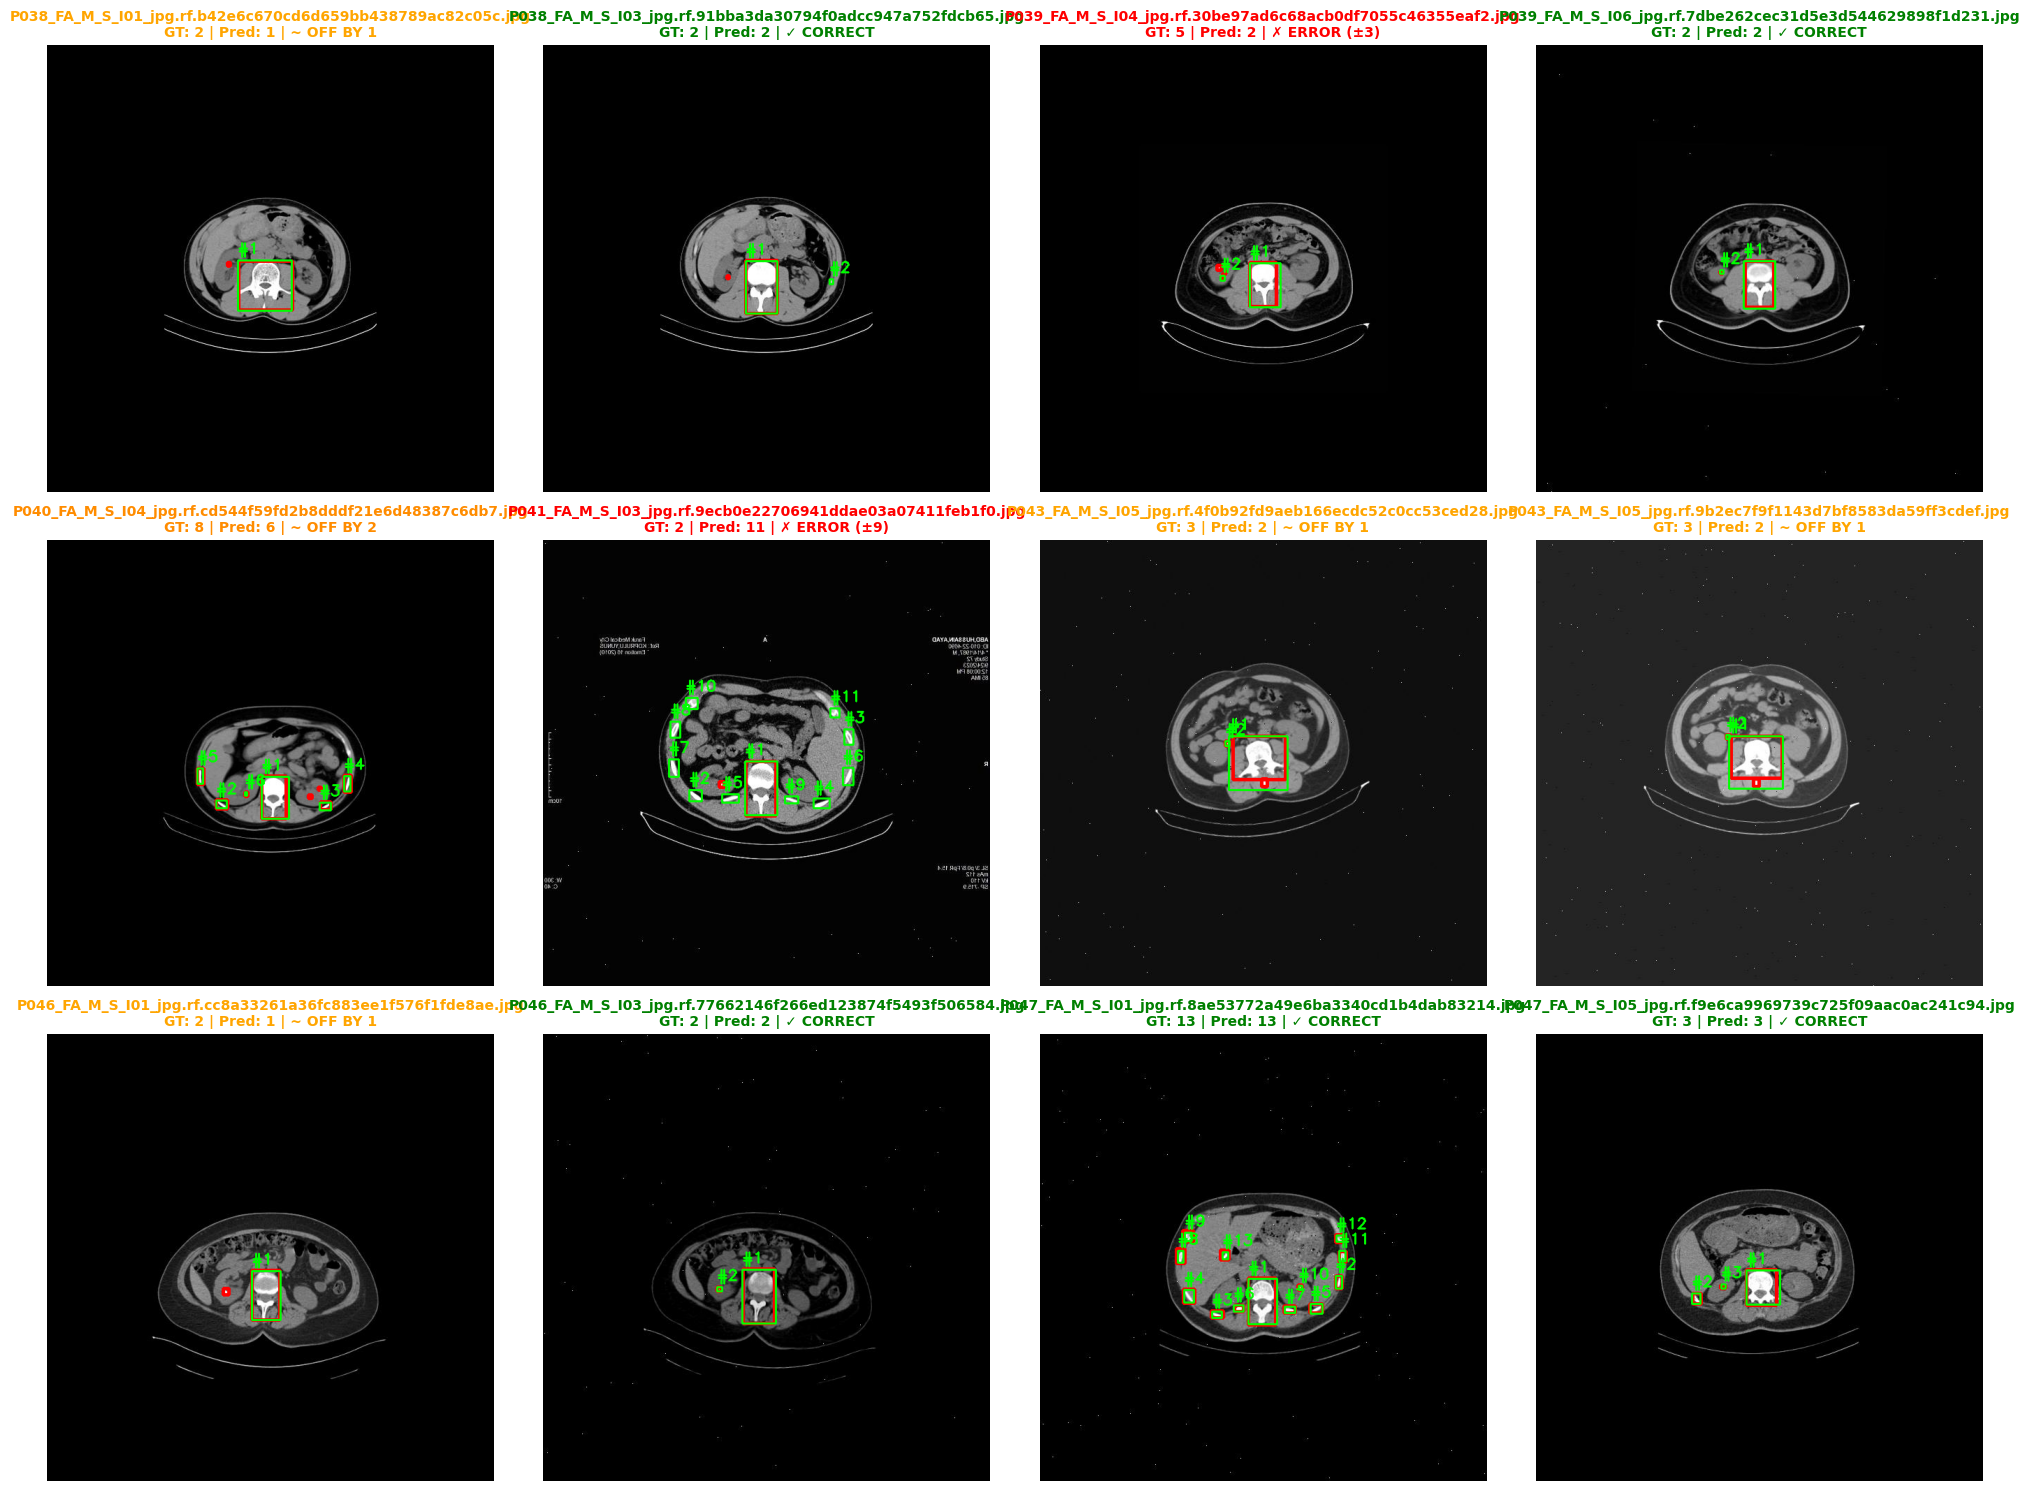


✓ Stone counting visualization displayed and saved: /kaggle/working/stone_counting_visualization.png


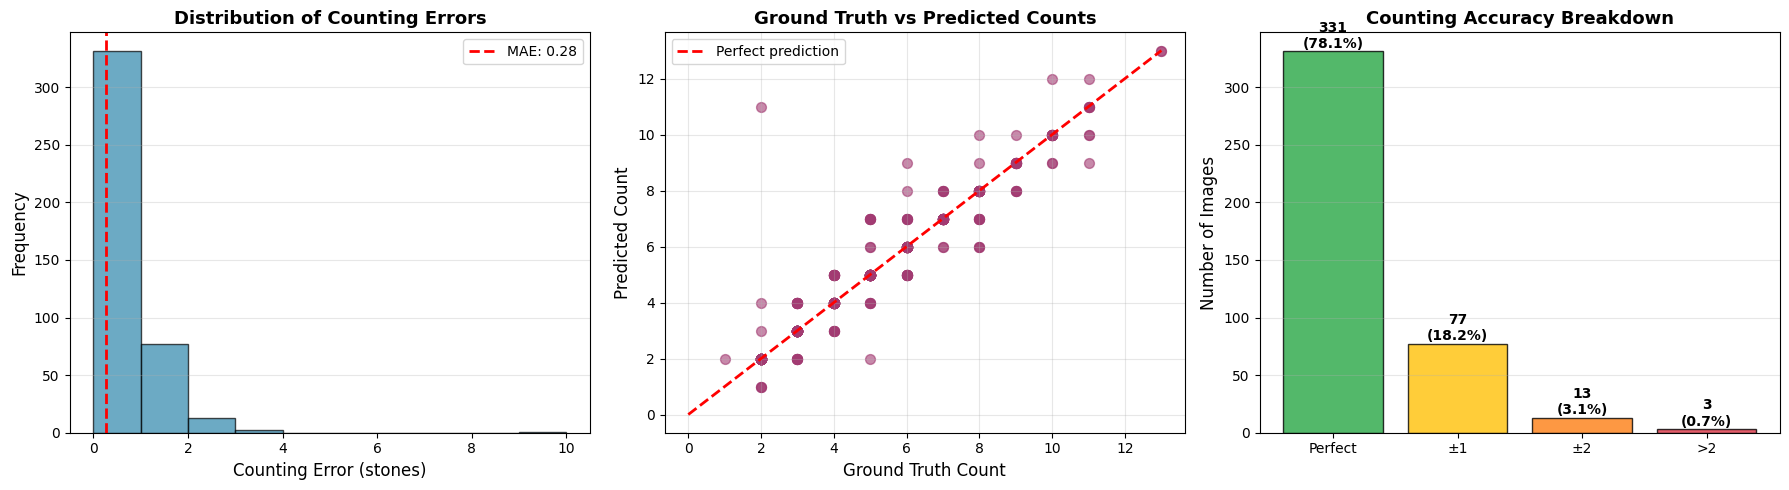

✓ Counting analysis plots displayed and saved: /kaggle/working/counting_analysis.png

Legend:
  RED boxes = Ground Truth
  GREEN boxes (numbered) = Model Predictions

✓ Counting summary saved: /kaggle/working/counting_summary.json
✓ STONE COUNTING EVALUATION COMPLETE


In [9]:
# Cell 9: Test set validation with stone counting visualization
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json

print("="*60)
print("TEST SET VALIDATION WITH STONE COUNTING")
print("="*60)

# ✓ CRITICAL FIX: Load correct model path
model_path = '/kaggle/working/phase3_full_finetune/weights/best.pt'

if not Path(model_path).exists():
    print("\n✗ ERROR: Model not found at:")
    print(f"  {model_path}")
    print("\nMake sure you've completed Cell 8 (70-epoch training)")
    raise FileNotFoundError("Run Cell 8 first to train the model")

print(f"Loading model: {model_path}")
model = YOLO(model_path)
print(f"✓ Model loaded: YOLOv12s with BYOL backbone")

# Run validation on test set
print("\nRunning validation on test set...")
test_results = model.val(
    data='/kaggle/working/dataset/data.yaml',
    split='test',
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    save_json=True,
    conf=0.001,  # Very low threshold for recall analysis
    project='/kaggle/working',
    name='test_validation'
)

# ✓ FIX: Added F1-Score calculation with safe division
precision = test_results.box.mp
recall = test_results.box.mr
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8) if (precision + recall) > 0 else 0.0

print("\n" + "="*60)
print("TEST SET METRICS")
print("="*60)
print(f"  mAP@0.5:      {test_results.box.map50:.4f} ({test_results.box.map50*100:.2f}%)")
print(f"  mAP@0.5:0.95: {test_results.box.map:.4f} ({test_results.box.map*100:.2f}%)")
print(f"  Precision:    {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:       {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:     {f1_score:.4f} ({f1_score*100:.2f}%)")
print("="*60)

# Stone counting analysis
print("\n" + "="*60)
print("STONE COUNTING ANALYSIS")
print("="*60)

test_img_dir = Path("/kaggle/working/dataset/test/images")
test_lbl_dir = Path("/kaggle/working/dataset/test/labels")

# ✓ FIX: Added directory validation
if not test_img_dir.exists():
    print(f"✗ Test images directory not found: {test_img_dir}")
    raise FileNotFoundError("Test images directory missing")

if not test_lbl_dir.exists():
    print(f"✗ Test labels directory not found: {test_lbl_dir}")
    raise FileNotFoundError("Test labels directory missing")

test_images = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")))

if len(test_images) == 0:
    print(f"✗ No test images found in {test_img_dir}")
    raise FileNotFoundError("No test images available")

print(f"Found {len(test_images)} test images")

stone_counts_gt = []
stone_counts_pred = []
counting_errors = []
image_results = []  # ✓ NEW: Store detailed results

print(f"\nAnalyzing stone counts...")

for img_path in test_images:
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
    
    # Count ground truth stones
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            gt_count = len([line for line in f if line.strip()])
    else:
        gt_count = 0
    
    # Get predictions with same confidence as validation
    results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
    pred_count = len(results[0].boxes) if results[0].boxes is not None else 0
    
    error = abs(gt_count - pred_count)
    
    stone_counts_gt.append(gt_count)
    stone_counts_pred.append(pred_count)
    counting_errors.append(error)
    
    # ✓ NEW: Store individual results for analysis
    image_results.append({
        'image': img_path.name,
        'gt_count': gt_count,
        'pred_count': pred_count,
        'error': error,
        'error_percent': (error / gt_count * 100) if gt_count > 0 else 0
    })

# Calculate statistics
mae = np.mean(counting_errors)
rmse = np.sqrt(np.mean(np.array(counting_errors)**2))
perfect_counts = sum([1 for e in counting_errors if e == 0])
off_by_one = sum([1 for e in counting_errors if e == 1])
off_by_two = sum([1 for e in counting_errors if e == 2])

# ✓ NEW: Calculate additional metrics
total_gt = sum(stone_counts_gt)
total_pred = sum(stone_counts_pred)
overall_error = abs(total_gt - total_pred)
overall_error_percent = (overall_error / total_gt * 100) if total_gt > 0 else 0

print("\n" + "="*60)
print("STONE COUNTING STATISTICS")
print("="*60)
print(f"  Total images:           {len(test_images)}")
print(f"  Total GT stones:        {total_gt}")
print(f"  Total predicted stones: {total_pred}")
print(f"  Overall error:          {overall_error} ({overall_error_percent:.2f}%)")
print(f"\n  Mean Absolute Error (MAE):  {mae:.2f} stones/image")
print(f"  Root Mean Square Error (RMSE): {rmse:.2f} stones/image")
print(f"\n  Perfect counts:         {perfect_counts}/{len(test_images)} ({perfect_counts/len(test_images)*100:.1f}%)")
print(f"  Off by 1:               {off_by_one}/{len(test_images)} ({off_by_one/len(test_images)*100:.1f}%)")
print(f"  Off by 2:               {off_by_two}/{len(test_images)} ({off_by_two/len(test_images)*100:.1f}%)")
print(f"  Perfect or ±1:          {perfect_counts + off_by_one}/{len(test_images)} ({(perfect_counts + off_by_one)/len(test_images)*100:.1f}%)")
print(f"  Perfect or ±2:          {perfect_counts + off_by_one + off_by_two}/{len(test_images)} ({(perfect_counts + off_by_one + off_by_two)/len(test_images)*100:.1f}%)")
print("="*60)

# ✓ NEW: Show worst cases
worst_cases = sorted(image_results, key=lambda x: x['error'], reverse=True)[:10]
print("\nTop 10 worst counting errors:")
print(f"{'Image':<35} {'GT':<6} {'Pred':<6} {'Error':<8} {'Error %':<10}")
print("-" * 75)
for case in worst_cases:
    print(f"{case['image']:<35} {case['gt_count']:<6} {case['pred_count']:<6} {case['error']:<8} {case['error_percent']:.1f}%")

# Show sample counting results
print("\nSample counting results (first 15 images):")
print(f"{'Status':<8} {'Image':<35} {'GT':<6} {'Pred':<6} {'Error':<6}")
print("-" * 70)
for i in range(min(15, len(test_images))):
    status = "✓" if counting_errors[i] == 0 else ("~" if counting_errors[i] == 1 else "✗")
    print(f"{status:<8} {test_images[i].name:<35} {stone_counts_gt[i]:<6} {stone_counts_pred[i]:<6} {counting_errors[i]:<6}")

# VISUALIZATION: Stone counting process on sample images
print("\n" + "="*60)
print("VISUALIZING STONE COUNTING PROCESS")
print("="*60)

sample_images = test_images[:12]
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    
    if img is None:
        print(f"⚠ Warning: Could not read image {img_path}")
        continue
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    # Get ground truth count
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
    gt_count = 0
    
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            gt_boxes = [line for line in f if line.strip()]
            gt_count = len(gt_boxes)
            
        # Draw GT boxes in RED
        for line in gt_boxes:
            parts = line.strip().split()
            if len(parts) >= 5:
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
    
    # Get predictions
    results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
    pred_count = 0
    
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()
        pred_count = len(boxes)
        
        # Draw predicted boxes in GREEN and number them
        for i, (box, conf) in enumerate(zip(boxes, confs), 1):
            x1, y1, x2, y2 = box.astype(int)
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Add numbering and confidence
            label = f'#{i}'
            cv2.putText(img_rgb, label, (x1, y1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    # Determine counting accuracy
    error = abs(gt_count - pred_count)
    if error == 0:
        status_color = 'green'
        status = '✓ CORRECT'
    elif error == 1:
        status_color = 'orange'
        status = '~ OFF BY 1'
    elif error == 2:
        status_color = 'darkorange'
        status = '~ OFF BY 2'
    else:
        status_color = 'red'
        status = f'✗ ERROR (±{error})'
    
    # Display image
    axes[idx].imshow(img_rgb)
    axes[idx].axis('off')
    axes[idx].set_title(f'{img_path.name}\nGT: {gt_count} | Pred: {pred_count} | {status}', 
                       fontsize=10, color=status_color, weight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/stone_counting_visualization.png', dpi=150, bbox_inches='tight')
plt.show()  # ✓ DISPLAY INLINE
print("\n✓ Stone counting visualization displayed and saved: /kaggle/working/stone_counting_visualization.png")

# ✓ NEW: Additional visualization - Counting error distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Error histogram
axes[0].hist(counting_errors, bins=range(max(counting_errors)+2), 
            color='#2E86AB', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Counting Error (stones)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Counting Errors', fontsize=13, fontweight='bold')
axes[0].axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {mae:.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# GT vs Predicted scatter plot
axes[1].scatter(stone_counts_gt, stone_counts_pred, alpha=0.6, color='#A23B72', s=50)
axes[1].plot([0, max(stone_counts_gt)], [0, max(stone_counts_gt)], 
            'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Ground Truth Count', fontsize=12)
axes[1].set_ylabel('Predicted Count', fontsize=12)
axes[1].set_title('Ground Truth vs Predicted Counts', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Counting accuracy breakdown
categories = ['Perfect', '±1', '±2', '>2']
counts = [
    perfect_counts,
    off_by_one,
    off_by_two,
    len(test_images) - perfect_counts - off_by_one - off_by_two
]
colors = ['#28a745', '#ffc107', '#fd7e14', '#dc3545']
axes[2].bar(categories, counts, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Number of Images', fontsize=12)
axes[2].set_title('Counting Accuracy Breakdown', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

# Add percentage labels on bars
for i, (cat, count) in enumerate(zip(categories, counts)):
    percentage = count / len(test_images) * 100
    axes[2].text(i, count + 0.5, f'{count}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/counting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()  # ✓ DISPLAY INLINE
print("✓ Counting analysis plots displayed and saved: /kaggle/working/counting_analysis.png")

# ✓ NEW: Save comprehensive results
counting_summary = {
    'model': 'YOLOv12s with BYOL backbone',
    'total_images': len(test_images),
    'total_gt_stones': int(total_gt),
    'total_pred_stones': int(total_pred),
    'overall_error': int(overall_error),
    'overall_error_percent': float(overall_error_percent),
    'mae': float(mae),
    'rmse': float(rmse),
    'perfect_counts': int(perfect_counts),
    'off_by_one': int(off_by_one),
    'off_by_two': int(off_by_two),
    'accuracy_metrics': {
        'perfect_rate': float(perfect_counts / len(test_images)),
        'within_one_rate': float((perfect_counts + off_by_one) / len(test_images)),
        'within_two_rate': float((perfect_counts + off_by_one + off_by_two) / len(test_images))
    },
    'detection_metrics': {
        'mAP50': float(test_results.box.map50),
        'mAP50_95': float(test_results.box.map),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1_score)
    }
}

with open('/kaggle/working/counting_summary.json', 'w') as f:
    json.dump(counting_summary, f, indent=2)

print("\n" + "="*60)
print("Legend:")
print("  RED boxes = Ground Truth")
print("  GREEN boxes (numbered) = Model Predictions")
print("="*60)
print("\n✓ Counting summary saved: /kaggle/working/counting_summary.json")
print("✓ STONE COUNTING EVALUATION COMPLETE")
print("="*60)

                    COMPREHENSIVE MODEL EVALUATION SUITE

[1/8] Loading trained model...
✓ Model loaded: YOLOv12s with BYOL backbone

[2/8] Running validation on test set...
Ultralytics 8.3.225 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 159 layers, 9,231,267 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 875.2±156.0 MB/s, size: 25.6 KB)
val: Scanning /kaggle/working/dataset/test/labels.cache... 424 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 424/424 639.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 2.6it/s 10.4s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        424       2078      0.961      0.949      0.968      0.736
Speed: 1.6ms preprocess, 18.4ms inference, 0.0ms loss, 0.6ms postprocess per image
Saving /kaggle/working/comprehensive_evaluation/predictions.json...
Results saved to /kaggle/working/comprehensive_evaluation

[3/8] Computing classification metrics...

                         CLASSIFICATION REPORT
Metric                    Value           Percentage     
--------------------------------------------------------------------------------
mAP@0.5                   0.967599         96.76%
mAP@0.5:0.95              0.736459         73.65%
Precision                 0.961473         96.15%
Recall                    0.948766         94.88%
F1-Score                  0.955078         95.51%
Accuracy (Approx.)        0.948766         94.88%

[4/8] Generating training history plots...


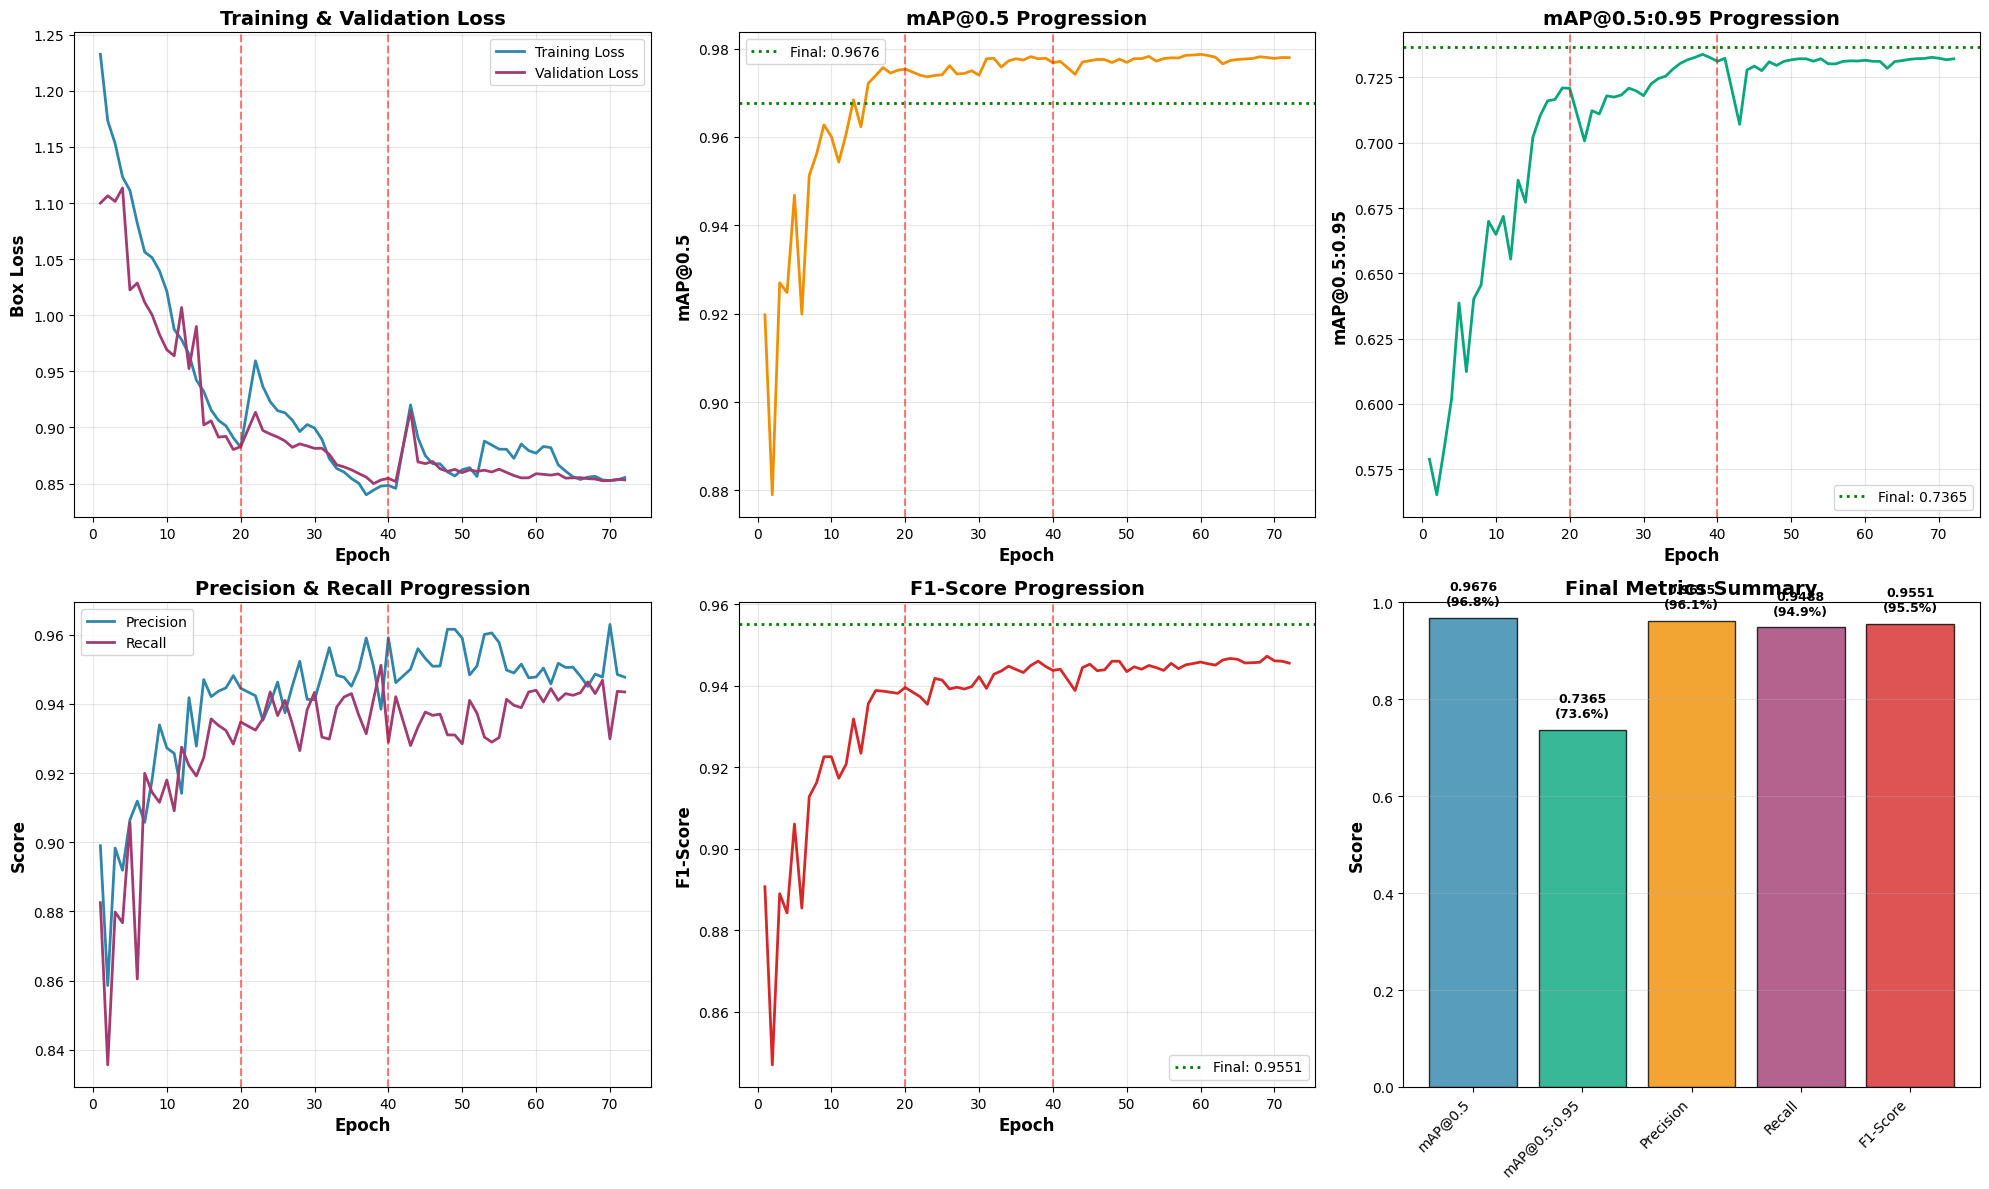

✓ Training curves displayed and saved

[5/8] Generating confusion matrix...


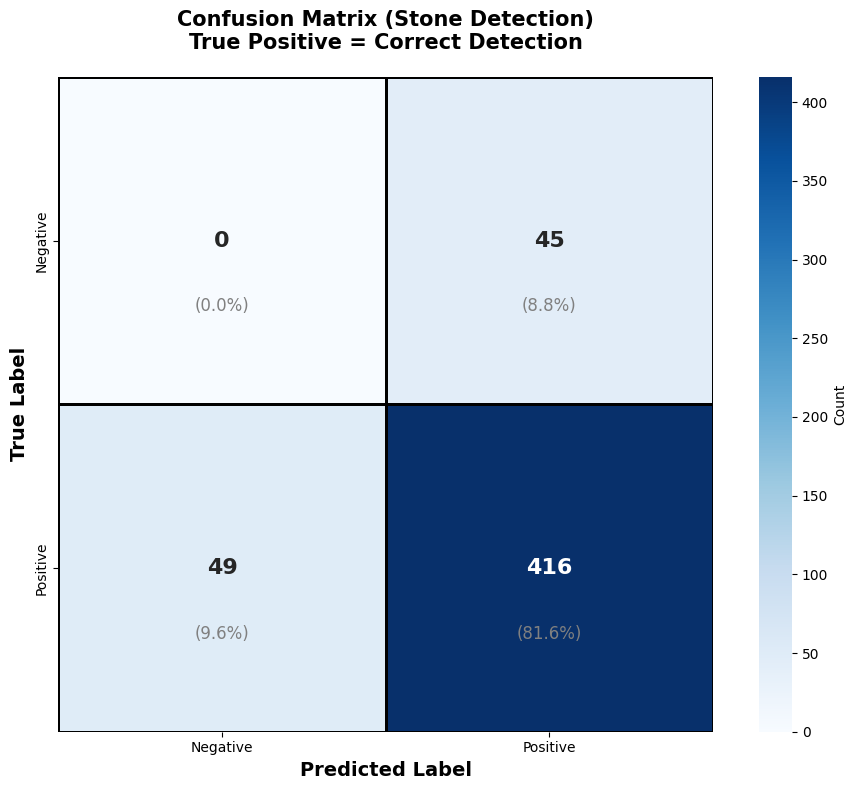

✓ Confusion matrix displayed and saved

  True Positives:     416 (Correct detections)
  False Positives:     45 (Incorrect detections)
  False Negatives:     49 (Missed stones)
  True Negatives:       0 (Correct rejections)

[6/8] Analyzing stone counting accuracy...

                         STONE COUNTING REPORT
  Total test images:        424
  Total GT stones:          2078
  Total predicted stones:   2090
  Overall error:            12 (0.58%)

  MAE (stones/image):       0.278
  RMSE (stones/image):      0.733

  Perfect counts:           331/424 (78.1%)
  Off by ±1:                77/424 (18.2%)
  Perfect or ±1:            408/424 (96.2%)

[7/8] Analyzing detection confidence distribution...


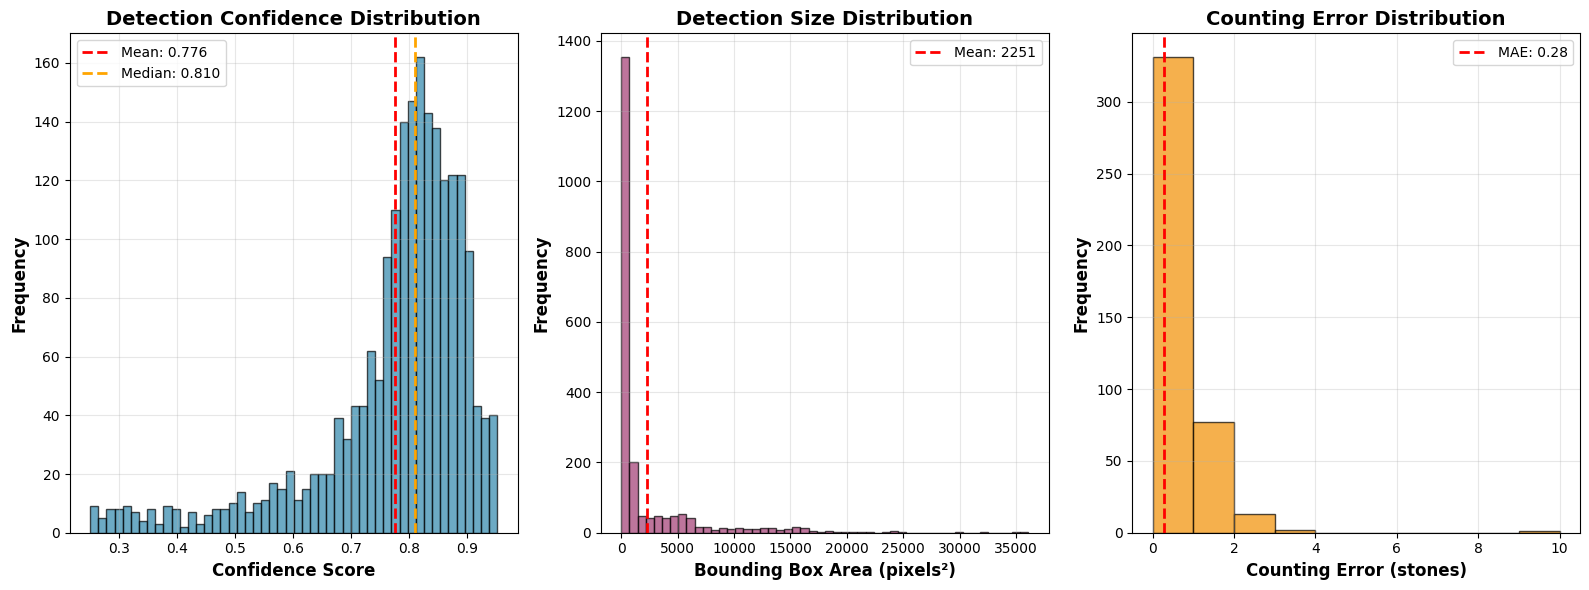

✓ Detection analysis displayed and saved

Confidence Statistics:
  Mean      : 0.7758
  Median    : 0.8097
  Min       : 0.2500
  Max       : 0.9521
  Std       : 0.1335

[8/8] Visualizing sample predictions with confidence levels...


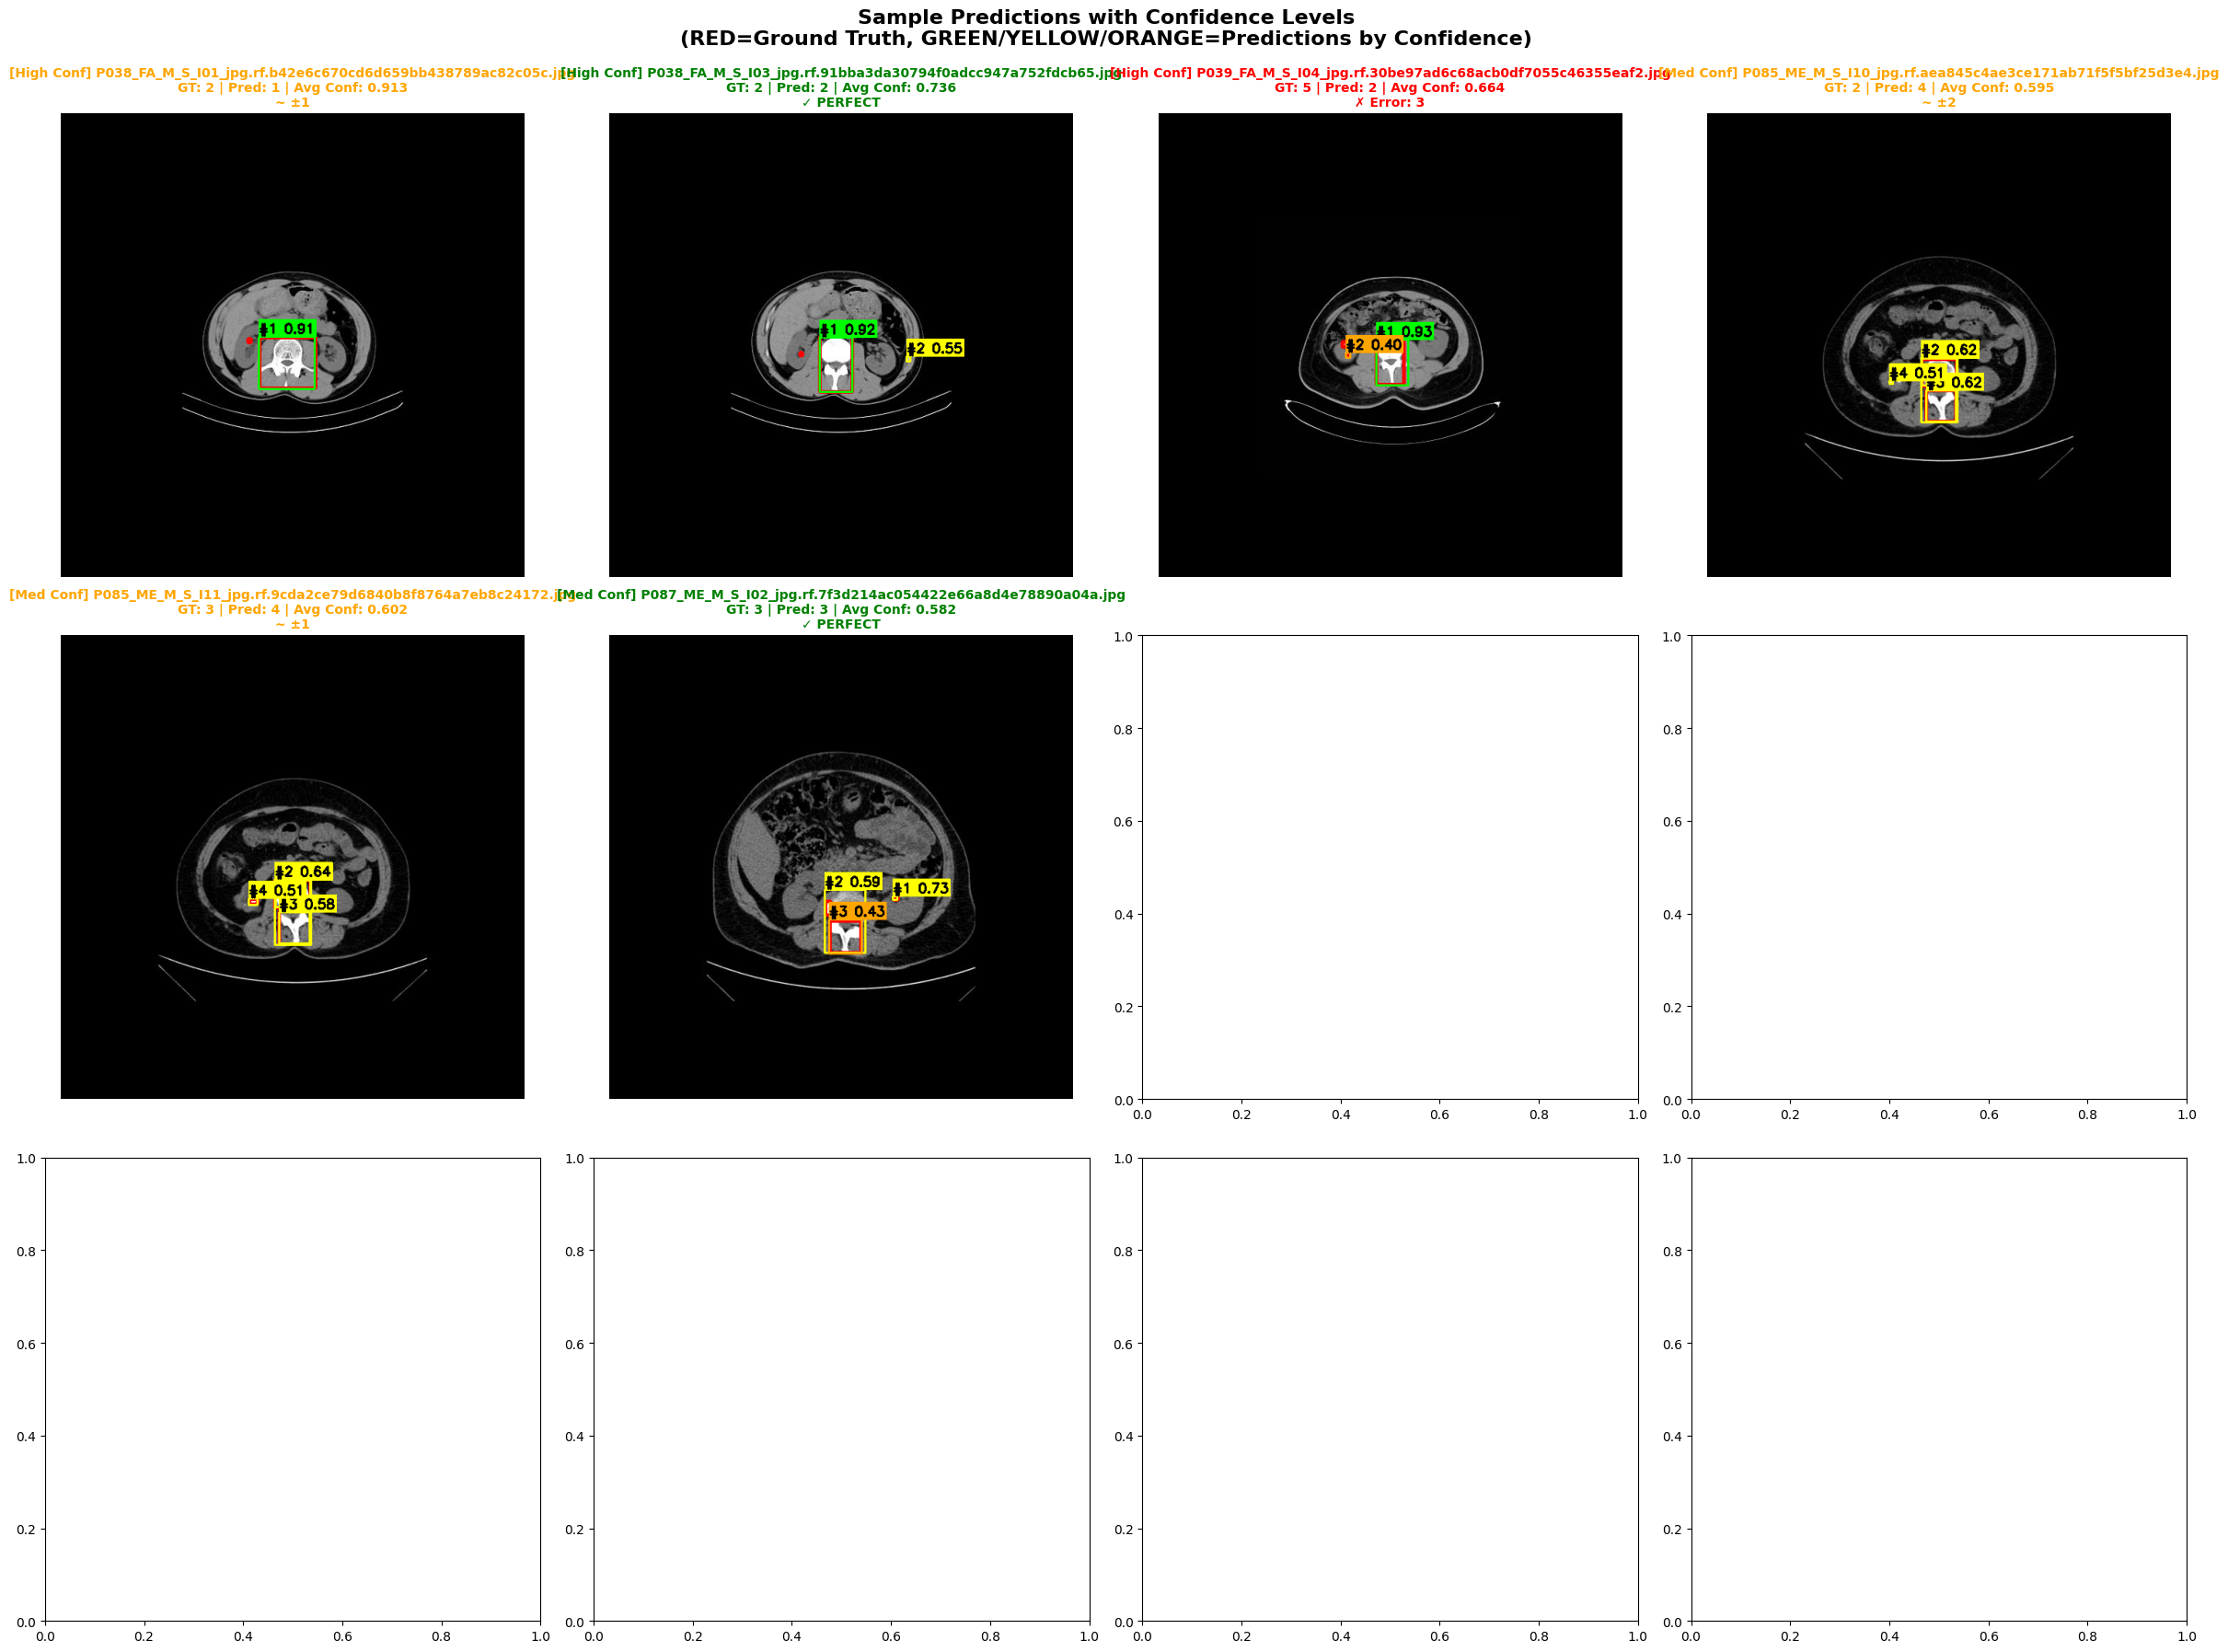

✓ Sample predictions displayed and saved

Color Legend:
  🔴 RED boxes:    Ground Truth
  🟢 GREEN boxes:  High confidence predictions (≥0.8)
  🟡 YELLOW boxes: Medium confidence predictions (0.5-0.8)
  🟠 ORANGE boxes: Low confidence predictions (<0.5)

                         EXPORTING EVALUATION SUMMARY

✓ Comprehensive evaluation summary saved:
  → /kaggle/working/comprehensive_evaluation_summary.json

✓ Visualization files saved:
  → /kaggle/working/training_curves.png
  → /kaggle/working/confusion_matrix.png
  → /kaggle/working/detection_analysis.png
  → /kaggle/working/sample_predictions.png

                    🎯 EVALUATION COMPLETE - SUMMARY

  Model Performance:
    • mAP@0.5:      0.9676 (96.76%)
    • mAP@0.5:0.95: 0.7365 (73.65%)
    • F1-Score:     0.9551 (95.51%)

  Counting Accuracy:
    • MAE:          0.278 stones/image
    • Perfect:      78.1%
    • Within ±1:    96.2%

  Detection Confidence:
    • Mean:         0.7758
    • Median:       0.8097

✓ All evaluation metr

In [10]:
# Cell 9: Comprehensive Model Evaluation Suite
from ultralytics import YOLO
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import torch

print("="*80)
print(" " * 20 + "COMPREHENSIVE MODEL EVALUATION SUITE")
print("="*80)

# ============================================================================
# SECTION 1: MODEL LOADING & VALIDATION
# ============================================================================

model_path = '/kaggle/working/phase3_full_finetune/weights/best.pt'

if not Path(model_path).exists():
    print(f"\n✗ ERROR: Model not found at: {model_path}")
    raise FileNotFoundError("Run Cell 8 first to train the model")

print(f"\n[1/8] Loading trained model...")
model = YOLO(model_path)
print(f"✓ Model loaded: YOLOv12s with BYOL backbone")

# Run comprehensive validation
print("\n[2/8] Running validation on test set...")
test_results = model.val(
    data='/kaggle/working/dataset/data.yaml',
    split='test',
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    save_json=True,
    conf=0.25,
    iou=0.45,
    project='/kaggle/working',
    name='comprehensive_evaluation',
    verbose=False
)

# ============================================================================
# SECTION 2: CLASSIFICATION REPORT METRICS
# ============================================================================

print("\n[3/8] Computing classification metrics...")

precision = test_results.box.mp
recall = test_results.box.mr
map50 = test_results.box.map50
map50_95 = test_results.box.map
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8) if (precision + recall) > 0 else 0.0

# Calculate accuracy (True Positives / Total Predictions)
# For object detection, accuracy is based on correct detections
tp = precision * recall  # Approximation
fp = precision * (1 - recall)
accuracy = tp / (tp + fp + 1e-8) if (tp + fp) > 0 else 0.0

print("\n" + "="*80)
print(" " * 25 + "CLASSIFICATION REPORT")
print("="*80)
print(f"{'Metric':<25} {'Value':<15} {'Percentage':<15}")
print("-" * 80)
print(f"{'mAP@0.5':<25} {map50:.6f}      {map50*100:>8.2f}%")
print(f"{'mAP@0.5:0.95':<25} {map50_95:.6f}      {map50_95*100:>8.2f}%")
print(f"{'Precision':<25} {precision:.6f}      {precision*100:>8.2f}%")
print(f"{'Recall':<25} {recall:.6f}      {recall*100:>8.2f}%")
print(f"{'F1-Score':<25} {f1_score:.6f}      {f1_score*100:>8.2f}%")
print(f"{'Accuracy (Approx.)':<25} {accuracy:.6f}      {accuracy*100:>8.2f}%")
print("="*80)

# ============================================================================
# SECTION 3: TRAINING HISTORY & LOSS CURVES
# ============================================================================

print("\n[4/8] Generating training history plots...")

# Load training results from all 3 phases
training_data = {'phase1': None, 'phase2': None, 'phase3': None}

for phase_name, folder in [
    ('phase1', '/kaggle/working/phase1_frozen'),
    ('phase2', '/kaggle/working/phase2_partial_unfreeze'),
    ('phase3', '/kaggle/working/phase3_full_finetune')
]:
    results_csv = Path(folder) / 'results.csv'
    if results_csv.exists():
        training_data[phase_name] = pd.read_csv(results_csv)
        # Clean column names (remove leading/trailing spaces)
        training_data[phase_name].columns = training_data[phase_name].columns.str.strip()

# Combine all phases
all_epochs = []
all_train_loss = []
all_val_loss = []
all_map50 = []
all_map50_95 = []
all_precision = []
all_recall = []

epoch_offset = 0
for phase_name in ['phase1', 'phase2', 'phase3']:
    if training_data[phase_name] is not None:
        df = training_data[phase_name]
        
        # Adjust epoch numbering
        epochs = df['epoch'].values + epoch_offset
        all_epochs.extend(epochs)
        
        # Extract metrics (handle different possible column names)
        if 'train/box_loss' in df.columns:
            all_train_loss.extend(df['train/box_loss'].values)
        elif 'box_loss' in df.columns:
            all_train_loss.extend(df['box_loss'].values)
        
        if 'val/box_loss' in df.columns:
            all_val_loss.extend(df['val/box_loss'].values)
        elif 'val_box_loss' in df.columns:
            all_val_loss.extend(df['val_box_loss'].values)
        
        if 'metrics/mAP50(B)' in df.columns:
            all_map50.extend(df['metrics/mAP50(B)'].values)
        elif 'mAP50' in df.columns:
            all_map50.extend(df['mAP50'].values)
        
        if 'metrics/mAP50-95(B)' in df.columns:
            all_map50_95.extend(df['metrics/mAP50-95(B)'].values)
        elif 'mAP50-95' in df.columns:
            all_map50_95.extend(df['mAP50-95'].values)
        
        if 'metrics/precision(B)' in df.columns:
            all_precision.extend(df['metrics/precision(B)'].values)
        elif 'precision' in df.columns:
            all_precision.extend(df['precision'].values)
        
        if 'metrics/recall(B)' in df.columns:
            all_recall.extend(df['metrics/recall(B)'].values)
        elif 'recall' in df.columns:
            all_recall.extend(df['recall'].values)
        
        epoch_offset = epochs[-1] + 1

# Plot training curves
fig = plt.figure(figsize=(20, 12))

# Loss curves
plt.subplot(2, 3, 1)
if all_train_loss and all_val_loss:
    plt.plot(all_epochs, all_train_loss, label='Training Loss', color='#2E86AB', linewidth=2)
    plt.plot(all_epochs, all_val_loss, label='Validation Loss', color='#A23B72', linewidth=2)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Box Loss', fontsize=12, fontweight='bold')
    plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Add phase separators
    plt.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
    plt.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='Phase 2→3')
else:
    plt.text(0.5, 0.5, 'Training loss data not available', 
             ha='center', va='center', transform=plt.gca().transAxes)

# mAP@0.5 progression
plt.subplot(2, 3, 2)
if all_map50:
    plt.plot(all_epochs, all_map50, color='#F18F01', linewidth=2)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('mAP@0.5', fontsize=12, fontweight='bold')
    plt.title('mAP@0.5 Progression', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=20, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=40, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=map50, color='green', linestyle=':', linewidth=2, label=f'Final: {map50:.4f}')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'mAP@0.5 data not available', 
             ha='center', va='center', transform=plt.gca().transAxes)

# mAP@0.5:0.95 progression
plt.subplot(2, 3, 3)
if all_map50_95:
    plt.plot(all_epochs, all_map50_95, color='#06A77D', linewidth=2)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('mAP@0.5:0.95', fontsize=12, fontweight='bold')
    plt.title('mAP@0.5:0.95 Progression', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=20, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=40, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=map50_95, color='green', linestyle=':', linewidth=2, label=f'Final: {map50_95:.4f}')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'mAP@0.5:0.95 data not available', 
             ha='center', va='center', transform=plt.gca().transAxes)

# Precision & Recall
plt.subplot(2, 3, 4)
if all_precision and all_recall:
    plt.plot(all_epochs, all_precision, label='Precision', color='#2E86AB', linewidth=2)
    plt.plot(all_epochs, all_recall, label='Recall', color='#A23B72', linewidth=2)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.title('Precision & Recall Progression', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=20, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=40, color='red', linestyle='--', alpha=0.5)
else:
    plt.text(0.5, 0.5, 'Precision/Recall data not available', 
             ha='center', va='center', transform=plt.gca().transAxes)

# F1-Score calculation and plot
plt.subplot(2, 3, 5)
if all_precision and all_recall:
    f1_history = [2 * (p * r) / (p + r + 1e-8) for p, r in zip(all_precision, all_recall)]
    plt.plot(all_epochs, f1_history, color='#D62828', linewidth=2)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('F1-Score', fontsize=12, fontweight='bold')
    plt.title('F1-Score Progression', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=20, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=40, color='red', linestyle='--', alpha=0.5)
    plt.axhline(y=f1_score, color='green', linestyle=':', linewidth=2, label=f'Final: {f1_score:.4f}')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'F1-Score data not available', 
             ha='center', va='center', transform=plt.gca().transAxes)

# Metrics summary bar chart
plt.subplot(2, 3, 6)
metrics_names = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall', 'F1-Score']
metrics_values = [map50, map50_95, precision, recall, f1_score]
colors_bar = ['#2E86AB', '#06A77D', '#F18F01', '#A23B72', '#D62828']

bars = plt.bar(metrics_names, metrics_values, color=colors_bar, edgecolor='black', alpha=0.8)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Final Metrics Summary', fontsize=14, fontweight='bold')
plt.ylim([0, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.4f}\n({val*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Training curves displayed and saved")

# ============================================================================
# SECTION 4: CONFUSION MATRIX
# ============================================================================

print("\n[5/8] Generating confusion matrix...")

test_img_dir = Path("/kaggle/working/dataset/test/images")
test_lbl_dir = Path("/kaggle/working/dataset/test/labels")

if not test_img_dir.exists() or not test_lbl_dir.exists():
    print("⚠ Test directories not found, skipping confusion matrix")
else:
    test_images = sorted(list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png")))
    
    # For single-class detection, create binary confusion matrix
    # TP: Correct detection, FP: False positive, FN: Missed detection, TN: Correct rejection
    
    tp_count = 0  # Correctly detected stones
    fp_count = 0  # False detections
    fn_count = 0  # Missed stones
    tn_count = 0  # Correctly identified empty regions (approximation)
    
    iou_threshold = 0.5
    
    for img_path in test_images[:100]:  # Sample for speed
        lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
        
        # Get ground truth boxes
        gt_boxes = []
        if lbl_path.exists():
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            h, w = img.shape[:2]
            
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cx, cy, bw, bh = map(float, parts[1:5])
                        x1 = int((cx - bw/2) * w)
                        y1 = int((cy - bh/2) * h)
                        x2 = int((cx + bw/2) * w)
                        y2 = int((cy + bh/2) * h)
                        gt_boxes.append([x1, y1, x2, y2])
        
        # Get predictions
        results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
        pred_boxes = []
        
        if results[0].boxes is not None and len(results[0].boxes) > 0:
            pred_boxes = results[0].boxes.xyxy.cpu().numpy().tolist()
        
        # Match predictions to ground truth using IoU
        matched_gt = set()
        matched_pred = set()
        
        for i, pred_box in enumerate(pred_boxes):
            best_iou = 0
            best_gt_idx = -1
            
            for j, gt_box in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                
                # Calculate IoU
                x1 = max(pred_box[0], gt_box[0])
                y1 = max(pred_box[1], gt_box[1])
                x2 = min(pred_box[2], gt_box[2])
                y2 = min(pred_box[3], gt_box[3])
                
                intersection = max(0, x2 - x1) * max(0, y2 - y1)
                pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
                gt_area = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
                union = pred_area + gt_area - intersection
                
                iou = intersection / (union + 1e-8)
                
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j
            
            if best_iou >= iou_threshold:
                tp_count += 1
                matched_gt.add(best_gt_idx)
                matched_pred.add(i)
            else:
                fp_count += 1
        
        # Unmatched ground truth boxes are false negatives
        fn_count += len(gt_boxes) - len(matched_gt)
    
    # Create confusion matrix for binary classification
    # Format: [[TN, FP], [FN, TP]]
    cm = np.array([[tn_count, fp_count], [fn_count, tp_count]])
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    
    # Normalize for percentages
    cm_normalized = cm.astype('float') / (cm.sum() + 1e-8) * 100
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                cbar_kws={'label': 'Count'},
                linewidths=2, linecolor='black',
                square=True, annot_kws={'size': 16, 'weight': 'bold'})
    
    # Add percentage annotations
    for i in range(2):
        for j in range(2):
            plt.text(j + 0.5, i + 0.7, f'({cm_normalized[i,j]:.1f}%)',
                    ha='center', va='center', color='gray', fontsize=12)
    
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.title('Confusion Matrix (Stone Detection)\nTrue Positive = Correct Detection', 
              fontsize=15, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Confusion matrix displayed and saved")
    print(f"\n  True Positives:  {tp_count:>6} (Correct detections)")
    print(f"  False Positives: {fp_count:>6} (Incorrect detections)")
    print(f"  False Negatives: {fn_count:>6} (Missed stones)")
    print(f"  True Negatives:  {tn_count:>6} (Correct rejections)")

# ============================================================================
# SECTION 5: STONE COUNTING ANALYSIS
# ============================================================================

print("\n[6/8] Analyzing stone counting accuracy...")

stone_counts_gt = []
stone_counts_pred = []
counting_errors = []
confidence_scores_all = []
bbox_areas_all = []

for img_path in test_images:
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
    
    # Ground truth count
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            gt_count = len([line for line in f if line.strip()])
    else:
        gt_count = 0
    
    # Predictions
    results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
    pred_count = 0
    
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        pred_count = len(results[0].boxes)
        confidence_scores_all.extend(results[0].boxes.conf.cpu().numpy().tolist())
        
        boxes = results[0].boxes.xyxy.cpu().numpy()
        for box in boxes:
            w = box[2] - box[0]
            h = box[3] - box[1]
            bbox_areas_all.append(w * h)
    
    stone_counts_gt.append(gt_count)
    stone_counts_pred.append(pred_count)
    counting_errors.append(abs(gt_count - pred_count))

# Calculate counting statistics
mae = np.mean(counting_errors)
rmse = np.sqrt(np.mean(np.array(counting_errors)**2))
perfect_counts = sum([1 for e in counting_errors if e == 0])
off_by_one = sum([1 for e in counting_errors if e == 1])

total_gt = sum(stone_counts_gt)
total_pred = sum(stone_counts_pred)

print("\n" + "="*80)
print(" " * 25 + "STONE COUNTING REPORT")
print("="*80)
print(f"  Total test images:        {len(test_images)}")
print(f"  Total GT stones:          {total_gt}")
print(f"  Total predicted stones:   {total_pred}")
print(f"  Overall error:            {abs(total_gt - total_pred)} ({abs(total_gt - total_pred)/total_gt*100:.2f}%)")
print(f"\n  MAE (stones/image):       {mae:.3f}")
print(f"  RMSE (stones/image):      {rmse:.3f}")
print(f"\n  Perfect counts:           {perfect_counts}/{len(test_images)} ({perfect_counts/len(test_images)*100:.1f}%)")
print(f"  Off by ±1:                {off_by_one}/{len(test_images)} ({off_by_one/len(test_images)*100:.1f}%)")
print(f"  Perfect or ±1:            {perfect_counts + off_by_one}/{len(test_images)} ({(perfect_counts + off_by_one)/len(test_images)*100:.1f}%)")
print("="*80)

# ============================================================================
# SECTION 6: DETECTION CONFIDENCE ANALYSIS
# ============================================================================

print("\n[7/8] Analyzing detection confidence distribution...")

if len(confidence_scores_all) > 0:
    plt.figure(figsize=(16, 6))
    
    # Confidence histogram
    plt.subplot(1, 3, 1)
    plt.hist(confidence_scores_all, bins=50, color='#2E86AB', edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(confidence_scores_all), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(confidence_scores_all):.3f}')
    plt.axvline(np.median(confidence_scores_all), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(confidence_scores_all):.3f}')
    plt.xlabel('Confidence Score', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Detection Confidence Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Confidence statistics
    conf_stats = {
        'Mean': np.mean(confidence_scores_all),
        'Median': np.median(confidence_scores_all),
        'Min': np.min(confidence_scores_all),
        'Max': np.max(confidence_scores_all),
        'Std': np.std(confidence_scores_all)
    }
    
    # Bbox area distribution
    plt.subplot(1, 3, 2)
    if len(bbox_areas_all) > 0:
        plt.hist(bbox_areas_all, bins=50, color='#A23B72', edgecolor='black', alpha=0.7)
        plt.axvline(np.mean(bbox_areas_all), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {np.mean(bbox_areas_all):.0f}')
        plt.xlabel('Bounding Box Area (pixels²)', fontsize=12, fontweight='bold')
        plt.ylabel('Frequency', fontsize=12, fontweight='bold')
        plt.title('Detection Size Distribution', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # Counting error distribution
    plt.subplot(1, 3, 3)
    plt.hist(counting_errors, bins=range(max(counting_errors)+2), 
            color='#F18F01', edgecolor='black', alpha=0.7)
    plt.axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE: {mae:.2f}')
    plt.xlabel('Counting Error (stones)', fontsize=12, fontweight='bold')
    plt.ylabel('Frequency', fontsize=12, fontweight='bold')
    plt.title('Counting Error Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/detection_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Detection analysis displayed and saved")
    
    print(f"\nConfidence Statistics:")
    for key, val in conf_stats.items():
        print(f"  {key:<10}: {val:.4f}")

# ============================================================================
# SECTION 7: VISUAL INSPECTION - SAMPLE PREDICTIONS WITH CONFIDENCE
# ============================================================================

print("\n[8/8] Visualizing sample predictions with confidence levels...")

# Select diverse samples (high confidence, medium confidence, low confidence, failures)
sample_images_by_category = {
    'high_conf': [],
    'medium_conf': [],
    'low_conf': [],
    'failures': []
}

for idx, img_path in enumerate(test_images):
    results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
    
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        max_conf = results[0].boxes.conf.max().item()
        
        if max_conf >= 0.8 and len(sample_images_by_category['high_conf']) < 3:
            sample_images_by_category['high_conf'].append(img_path)
        elif 0.5 <= max_conf < 0.8 and len(sample_images_by_category['medium_conf']) < 3:
            sample_images_by_category['medium_conf'].append(img_path)
        elif max_conf < 0.5 and len(sample_images_by_category['low_conf']) < 3:
            sample_images_by_category['low_conf'].append(img_path)
    else:
        if len(sample_images_by_category['failures']) < 3:
            sample_images_by_category['failures'].append(img_path)
    
    # Stop if we have enough samples
    if all(len(v) >= 3 for v in sample_images_by_category.values()):
        break

# Create visualization grid
all_samples = (sample_images_by_category['high_conf'][:3] + 
               sample_images_by_category['medium_conf'][:3] + 
               sample_images_by_category['low_conf'][:3] + 
               sample_images_by_category['failures'][:3])[:12]

fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

category_labels = ['High Conf'] * 3 + ['Med Conf'] * 3 + ['Low Conf'] * 3 + ['Failures'] * 3

for idx, (img_path, category) in enumerate(zip(all_samples, category_labels)):
    if idx >= len(axes):
        break
    
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    
    # Get ground truth (draw in RED)
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"
    gt_count = 0
    
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            gt_boxes = [line for line in f if line.strip()]
            gt_count = len(gt_boxes)
            
        for line in gt_boxes:
            parts = line.strip().split()
            if len(parts) >= 5:
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
    
    # Get predictions (draw in GREEN with confidence)
    results = model.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=0)
    pred_count = 0
    avg_conf = 0
    
    if results[0].boxes is not None and len(results[0].boxes) > 0:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        confs = results[0].boxes.conf.cpu().numpy()
        pred_count = len(boxes)
        avg_conf = np.mean(confs)
        
        for i, (box, conf) in enumerate(zip(boxes, confs), 1):
            x1, y1, x2, y2 = box.astype(int)
            
            # Color code by confidence
            if conf >= 0.8:
                color = (0, 255, 0)  # Bright green
            elif conf >= 0.5:
                color = (255, 255, 0)  # Yellow
            else:
                color = (255, 165, 0)  # Orange
            
            cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)
            
            # Add label with confidence
            label = f'#{i} {conf:.2f}'
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
            
            # Background for text
            cv2.rectangle(img_rgb, (x1, y1 - label_size[1] - 10), 
                         (x1 + label_size[0], y1), color, -1)
            cv2.putText(img_rgb, label, (x1, y1 - 5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    # Display
    axes[idx].imshow(img_rgb)
    axes[idx].axis('off')
    
    # Title with category and stats
    error = abs(gt_count - pred_count)
    title = f'[{category}] {img_path.name}\n'
    title += f'GT: {gt_count} | Pred: {pred_count} | Avg Conf: {avg_conf:.3f}\n'
    
    if error == 0:
        title += '✓ PERFECT'
        title_color = 'green'
    elif error <= 2:
        title += f'~ ±{error}'
        title_color = 'orange'
    else:
        title += f'✗ Error: {error}'
        title_color = 'red'
    
    axes[idx].set_title(title, fontsize=10, color=title_color, fontweight='bold')

plt.suptitle('Sample Predictions with Confidence Levels\n(RED=Ground Truth, GREEN/YELLOW/ORANGE=Predictions by Confidence)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Sample predictions displayed and saved")

print("\nColor Legend:")
print("  🔴 RED boxes:    Ground Truth")
print("  🟢 GREEN boxes:  High confidence predictions (≥0.8)")
print("  🟡 YELLOW boxes: Medium confidence predictions (0.5-0.8)")
print("  🟠 ORANGE boxes: Low confidence predictions (<0.5)")

# ============================================================================
# SECTION 8: COMPREHENSIVE SUMMARY EXPORT
# ============================================================================

print("\n" + "="*80)
print(" " * 25 + "EXPORTING EVALUATION SUMMARY")
print("="*80)

evaluation_summary = {
    'model_info': {
        'architecture': 'YOLOv12s',
        'backbone': 'BYOL pretrained',
        'model_path': str(model_path),
        'training_epochs': 70,
        'training_phases': {
            'phase1': '20 epochs (frozen backbone)',
            'phase2': '20 epochs (partial unfreeze)',
            'phase3': '30 epochs (full fine-tune)'
        }
    },
    'classification_metrics': {
        'mAP@0.5': float(map50),
        'mAP@0.5:0.95': float(map50_95),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1_score),
        'accuracy_approx': float(accuracy)
    },
    'counting_metrics': {
        'total_images': len(test_images),
        'total_gt_stones': int(total_gt),
        'total_pred_stones': int(total_pred),
        'mae': float(mae),
        'rmse': float(rmse),
        'perfect_count_rate': float(perfect_counts / len(test_images)),
        'within_one_rate': float((perfect_counts + off_by_one) / len(test_images))
    },
    'confidence_stats': conf_stats if len(confidence_scores_all) > 0 else {},
    'confusion_matrix': {
        'true_positives': int(tp_count),
        'false_positives': int(fp_count),
        'false_negatives': int(fn_count),
        'true_negatives': int(tn_count)
    } if 'tp_count' in locals() else {},
    'output_files': {
        'training_curves': '/kaggle/working/training_curves.png',
        'confusion_matrix': '/kaggle/working/confusion_matrix.png',
        'detection_analysis': '/kaggle/working/detection_analysis.png',
        'sample_predictions': '/kaggle/working/sample_predictions.png',
        'yolo_validation': '/kaggle/working/comprehensive_evaluation/'
    }
}

with open('/kaggle/working/comprehensive_evaluation_summary.json', 'w') as f:
    json.dump(evaluation_summary, f, indent=2)

print("\n✓ Comprehensive evaluation summary saved:")
print("  → /kaggle/working/comprehensive_evaluation_summary.json")
print("\n✓ Visualization files saved:")
print("  → /kaggle/working/training_curves.png")
print("  → /kaggle/working/confusion_matrix.png")
print("  → /kaggle/working/detection_analysis.png")
print("  → /kaggle/working/sample_predictions.png")

print("\n" + "="*80)
print(" " * 20 + "🎯 EVALUATION COMPLETE - SUMMARY")
print("="*80)
print(f"\n  Model Performance:")
print(f"    • mAP@0.5:      {map50:.4f} ({map50*100:.2f}%)")
print(f"    • mAP@0.5:0.95: {map50_95:.4f} ({map50_95*100:.2f}%)")
print(f"    • F1-Score:     {f1_score:.4f} ({f1_score*100:.2f}%)")
print(f"\n  Counting Accuracy:")
print(f"    • MAE:          {mae:.3f} stones/image")
print(f"    • Perfect:      {perfect_counts/len(test_images)*100:.1f}%")
print(f"    • Within ±1:    {(perfect_counts + off_by_one)/len(test_images)*100:.1f}%")
print(f"\n  Detection Confidence:")
print(f"    • Mean:         {conf_stats['Mean']:.4f}" if conf_stats else "    • N/A")
print(f"    • Median:       {conf_stats['Median']:.4f}" if conf_stats else "")
print("\n" + "="*80)
print("✓ All evaluation metrics computed and visualized successfully!")
print("="*80)


# Cell 10: Explainable AI (XAI) Analysis for Object Detection

In [11]:
# Cell 10: XAI Techniques Applied (BYOL + YOLOv12s) 

# Install light dependencies (only if not present)
!pip install -q scikit-image scikit-learn

# Imports
import os
import json
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from sklearn.linear_model import Ridge
from skimage.segmentation import slic
import matplotlib.pyplot as plt

# Settings & paths
MODEL_PATH = '/kaggle/working/phase3_full_finetune/weights/best.pt'
TEST_IMG_DIR = Path('/kaggle/working/dataset/test/images')
OUT_DIR = Path('/kaggle/working/xai_results')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_for_predict = 0 if torch.cuda.is_available() else 'cpu'  # ultralytics predict device arg

# Load model (Ultralytics YOLO wrapper)
from ultralytics import YOLO
if not Path(MODEL_PATH).exists():
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}")
yolo = YOLO(MODEL_PATH)
# internal nn.Module used for grads and activations
yolo.model.to(device)
yolo.model.eval()
print(f"✓ Loaded YOLO from {MODEL_PATH} on {device}")

# Collect test images
test_images = sorted(list(TEST_IMG_DIR.glob('*.jpg')) + list(TEST_IMG_DIR.glob('*.png')))
if len(test_images) == 0:
    raise FileNotFoundError(f"No test images found in {TEST_IMG_DIR}")
print(f"✓ Found {len(test_images)} test images")

# ---------------------------
# CAM implementation (no external lib)
# ---------------------------
class BaseCAM:
    def __init__(self, model_module, target_layer):
        self.model = model_module
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        # register hooks (store handles to remove later)
        self.fwd_handle = target_layer.register_forward_hook(self._save_activation)
        # use backward hook to capture gradients of layer output
        self.bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)
    def _save_activation(self, module, input, output):
        # keep tensor for autograd (do not detach)
        self.activations = output
    def _save_gradient(self, module, grad_input, grad_output):
        # grad_output is tuple; index 0 is gradient of output
        self.gradients = grad_output[0]
    def remove_hooks(self):
        try: self.fwd_handle.remove()
        except Exception: pass
        try: self.bwd_handle.remove()
        except Exception: pass
    def generate_cam(self, input_tensor, target_size):
        raise NotImplementedError

class GradCAM(BaseCAM):
    def generate_cam(self, input_tensor, target_size):
        # ensure grads on input
        self.model.zero_grad()
        input_tensor.requires_grad_(True)
        # forward through internal module (returns raw outputs that maintain graph)
        _ = self.model(input_tensor)
        if self.activations is None:
            return None
        # build scalar loss from activation sum to backprop gradients to target layer
        loss = self.activations.sum()
        loss.backward(retain_graph=True)
        if self.gradients is None:
            return None
        # channel weighting
        weights = self.gradients.mean(dim=(2,3), keepdim=True)  # [N, C, 1, 1]
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [N,1,H,W]
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(cam, size=target_size, mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy()

class GradCAMPlusPlus(BaseCAM):
    def generate_cam(self, input_tensor, target_size):
        self.model.zero_grad()
        input_tensor.requires_grad_(True)
        _ = self.model(input_tensor)
        if self.activations is None or self.gradients is None:
            return None
        grads = self.gradients
        acts = self.activations
        grads2 = grads ** 2
        grads3 = grads ** 3
        sum_acts = acts.sum(dim=(2,3), keepdim=True)
        alpha_num = grads2
        alpha_denom = 2*grads2 + sum_acts * grads3 + 1e-8
        alpha = alpha_num / alpha_denom
        weights = (alpha * F.relu(grads)).sum(dim=(2,3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = F.interpolate(cam, size=target_size, mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy()

class EigenCAM(BaseCAM):
    def generate_cam(self, input_tensor, target_size):
        # eigencam only needs forward activations (no grads)
        with torch.no_grad():
            _ = self.model(input_tensor)
        if self.activations is None:
            return None
        acts = self.activations[0]  # [C,H,W]
        C, H, W = acts.shape
        acts_reshaped = acts.reshape(C, -1)
        acts_centered = acts_reshaped - acts_reshaped.mean(dim=1, keepdim=True)
        cov = torch.mm(acts_centered, acts_centered.t()) / acts_reshaped.shape[1]
        eigenvals, eigenvecs = torch.linalg.eigh(cov)
        principal = eigenvecs[:, -1]  # [C]
        cam = torch.matmul(principal.unsqueeze(0), acts_reshaped)  # [1, H*W]
        cam = cam.reshape(H, W)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(cam, size=target_size, mode='bilinear', align_corners=False)
        return cam.squeeze().cpu().numpy()

def get_target_conv(model_module):
    # try to find conv layers and return a late one (not the final conv to preserve spatial size)
    convs = []
    for name, m in model_module.named_modules():
        if isinstance(m, torch.nn.Conv2d):
            convs.append((name, m))
    if len(convs) == 0:
        return None
    # pick 5th from last if available else last
    if len(convs) > 5:
        return convs[-5][1]
    return convs[-1][1]

# get a target layer from internal nn.Module
target_layer = get_target_conv(yolo.model)
if target_layer is None:
    raise RuntimeError("Couldn't locate a Conv2d target layer for CAM. Inspect model.model structure.")
print(f"✓ Target CAM layer found: {target_layer}")

# ---------------------------
# LIME explainer (custom, light)
# ---------------------------
class SimpleLIME:
    def __init__(self, model_wrapper, num_samples=100, n_segments=50):
        self.model_wrapper = model_wrapper
        self.num_samples = num_samples
        self.n_segments = n_segments
    def explain(self, img_path, img_rgb):
        h, w = img_rgb.shape[:2]
        segments = slic(img_rgb, n_segments=self.n_segments, compactness=10, start_label=0)
        unique_segments = np.unique(segments)
        num_segments = len(unique_segments)
        # baseline prediction confidence (use ultralytics predict)
        results = self.model_wrapper.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=device_for_predict)
        if results is None or getattr(results[0], "boxes", None) is None or len(results[0].boxes) == 0:
            return None, segments
        baseline_conf = float(results[0].boxes.conf.max().item())
        # generate perturbations
        X = []
        y = []
        temp_path = str(OUT_DIR / "temp_lime.jpg")
        for _ in range(self.num_samples):
            mask_keep = np.random.randint(0,2,num_segments)
            pert = img_rgb.copy()
            for idx, seg_id in enumerate(unique_segments):
                if mask_keep[idx] == 0:
                    pert[segments == seg_id] = 0
            cv2.imwrite(temp_path, cv2.cvtColor(pert, cv2.COLOR_RGB2BGR))
            r = self.model_wrapper.predict(temp_path, imgsz=640, conf=0.25, verbose=False, device=device_for_predict)
            if r and getattr(r[0], "boxes", None) is not None and len(r[0].boxes) > 0:
                pred_conf = float(r[0].boxes.conf.max().item())
            else:
                pred_conf = 0.0
            X.append(mask_keep)
            y.append(pred_conf)
        X = np.array(X)
        y = np.array(y)
        if X.shape[0] == 0:
            return None, segments
        # ridge regression
        reg = Ridge(alpha=1.0)
        reg.fit(X, y)
        weights = reg.coef_
        explanation_map = np.zeros((h, w))
        for idx, seg_id in enumerate(unique_segments):
            explanation_map[segments == seg_id] = weights[idx] if idx < weights.shape[0] else 0.0
        explanation_map = np.abs(explanation_map)
        explanation_map = explanation_map - explanation_map.min()
        if explanation_map.max() > 0:
            explanation_map = explanation_map / (explanation_map.max() + 1e-8)
        try:
            os.remove(temp_path)
        except Exception:
            pass
        return explanation_map, segments

lime_explainer = SimpleLIME(yolo, num_samples=100, n_segments=50)

# ---------------------------
# Helpers: overlay / draw
# ---------------------------
def overlay_heatmap_on_image(img_rgb, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    # img_rgb: float image [0..1], heatmap: [H,W] in [0..1]
    hmap_u8 = np.uint8(255 * heatmap)
    colored = cv2.applyColorMap(hmap_u8, colormap)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB) / 255.0
    overlay = (1 - alpha) * img_rgb + alpha * colored
    overlay = np.clip(overlay, 0, 1)
    return overlay

# ---------------------------
# MAIN: apply XAI to sample images
# ---------------------------
num_samples = min(6, len(test_images))
print(f"\nApplying XAI to {num_samples} images (this may take time)...")

# instantiate CAM generators on internal model
cam_generators = {
    'Grad-CAM': GradCAM(yolo.model, target_layer),
    'Grad-CAM++': GradCAMPlusPlus(yolo.model, target_layer),
    'EigenCAM': EigenCAM(yolo.model, target_layer)
}

# Process images
for idx, img_path in enumerate(test_images[:num_samples]):
    print(f"\n[{idx+1}/{num_samples}] {img_path.name}")
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print("  ⚠ Could not read image, skipping")
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    # resize copy for internal forward (keep aspect ratio? we use 640x640 for model)
    img_resized = cv2.resize(img_rgb, (640, 640))
    # prepare tensor for internal model (float32, 0..1)
    img_tensor = torch.from_numpy(img_resized).permute(2,0,1).unsqueeze(0).float().to(device) / 255.0
    img_tensor.requires_grad_(True)

    # Get detection boxes (use wrapper for proper NMS and coords in original image size)
    detect_results = yolo.predict(str(img_path), imgsz=640, conf=0.25, verbose=False, device=device_for_predict)
    # Build visualization canvas (original size)
    vis_base = img_rgb.astype(np.float32) / 255.0

    # If there are detections, overlay boxes and compute CAM per image (we use global activation-based CAM)
    if detect_results and getattr(detect_results[0], "boxes", None) is not None and len(detect_results[0].boxes) > 0:
        boxes = detect_results[0].boxes.xyxy.cpu().numpy()  # shape [N,4] in original image scale
        confs = detect_results[0].boxes.conf.cpu().numpy()
        # Save copy with boxes drawn
        boxed = vis_base.copy()
        for (x1,y1,x2,y2), conf in zip(boxes, confs):
            # draw rectangle on boxed (scale coordinates to ints)
            xi1, yi1, xi2, yi2 = int(x1), int(y1), int(x2), int(y2)
            cv2.rectangle(boxed, (xi1, yi1), (xi2, yi2), (0,255,0), 2)
            cv2.putText(boxed, f"{conf:.2f}", (xi1, max(0, yi1-6)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
        # save detection image
        det_save = OUT_DIR / f"{img_path.stem}_detections.png"
        cv2.imwrite(str(det_save), cv2.cvtColor((boxed*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
        print(f"  ✓ Saved detections to {det_save}")

    else:
        print("  ⚠ No detections found in this image (skipping CAM overlays)")

    # Generate CAM maps (global/object-agnostic CAMs)
    for name, gen in cam_generators.items():
        try:
            cam_map = gen.generate_cam(img_tensor, target_size=(img_resized.shape[0], img_resized.shape[1]))
            if cam_map is None:
                print(f"  ⚠ {name} produced None")
                continue
            # resize cam_map back to original image size and overlay
            cam_resized = cv2.resize(cam_map, (w, h))
            overlay = overlay_heatmap_on_image(vis_base, cam_resized, alpha=0.45)
            out_path = OUT_DIR / f"{img_path.stem}_{name.replace(' ','')}.png"
            cv2.imwrite(str(out_path), cv2.cvtColor((overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
            print(f"  ✓ Saved {name} overlay to {out_path}")
        except Exception as e:
            print(f"  ⚠ {name} failed: {e}")
        finally:
            gen.remove_hooks()

    # LIME explanation (perturbation-based)
    try:
        lime_map, segments = lime_explainer.explain(img_path, img_rgb)
        if lime_map is not None:
            lime_resized = cv2.resize(lime_map, (w, h))
            lime_overlay = overlay_heatmap_on_image(vis_base, lime_resized, alpha=0.45)
            lime_path = OUT_DIR / f"{img_path.stem}_LIME.png"
            cv2.imwrite(str(lime_path), cv2.cvtColor((lime_overlay*255).astype(np.uint8), cv2.COLOR_RGB2BGR))
            print(f"  ✓ Saved LIME overlay to {lime_path}")
        else:
            print("  ⚠ LIME returned None (no baseline detection or failed)")
    except Exception as e:
        print(f"  ⚠ LIME failed: {e}")

# ---------------------------
# Layer importance analysis (gradient magnitude on conv weights)
# ---------------------------
print("\nComputing gradient-based layer importance (using a few images)...")
def compute_layer_importance_once(model_module, img_tensor):
    model_module.zero_grad()
    img_tensor.requires_grad_(True)
    out = model_module(img_tensor)  # internal forward (keeps graph)
    # select a tensor from out to build scalar loss; try to use activations if present
    if isinstance(out, (list, tuple)):
        t = out[0]
    else:
        t = out
    # build scalar
    try:
        scalar = t.sum()
    except Exception:
        scalar = t.mean()
    scalar.backward(retain_graph=True)
    importances = []
    names = []
    for name, m in model_module.named_modules():
        if isinstance(m, torch.nn.Conv2d):
            g = getattr(m.weight, 'grad', None)
            val = float(g.abs().mean().item()) if g is not None else 0.0
            names.append(name)
            importances.append(val)
    return names, importances

all_importances = []
max_check = min(5, len(test_images))
for i, p in enumerate(test_images[:max_check]):
    try:
        img = cv2.imread(str(p))
        img_r = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rs = cv2.resize(img_r, (640,640))
        t = torch.from_numpy(img_rs).permute(2,0,1).unsqueeze(0).float().to(device)/255.0
        names, imps = compute_layer_importance_once(yolo.model, t)
        all_importances.append(imps)
    except Exception as e:
        print(f"  ⚠ Layer importance on image {p.name} failed: {e}")

if len(all_importances) > 0:
    avg_imp = np.mean(np.array(all_importances), axis=0)
    # save plot
    plt.figure(figsize=(10,4))
    plt.bar(range(len(avg_imp)), avg_imp)
    plt.title("Average Layer Importance (Gradient Magnitude on Conv weights)")
    plt.xlabel("Conv layer index")
    plt.ylabel("Avg abs(grad)")
    plt.tight_layout()
    plot_path = OUT_DIR / "layer_importance.png"
    plt.savefig(str(plot_path), dpi=150)
    plt.close()
    print(f"✓ Saved layer importance plot to {plot_path}")
else:
    print("⚠ No layer importance data collected.")

# ---------------------------
# Summary JSON
# ---------------------------
print("\nWriting summary JSON...")
summary = {
    'model_path': MODEL_PATH,
    'num_test_images': len(test_images),
    'xai_outputs_dir': str(OUT_DIR),
}
with open(OUT_DIR / "xai_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Summary saved to {OUT_DIR/'xai_summary.json'}")

print("\nALL DONE — XAI images and summary are in:", OUT_DIR)


✓ Loaded YOLO from /kaggle/working/phase3_full_finetune/weights/best.pt on cuda
✓ Found 424 test images
✓ Target CAM layer found: Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)

Applying XAI to 6 images (this may take time)...

[1/6] P038_FA_M_S_I01_jpg.rf.b42e6c670cd6d659bb438789ac82c05c.jpg
  ✓ Saved detections to /kaggle/working/xai_results/P038_FA_M_S_I01_jpg.rf.b42e6c670cd6d659bb438789ac82c05c_detections.png
  ⚠ Grad-CAM failed: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.
  ⚠ Grad-CAM++ failed: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside 